In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score, make_scorer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

from skopt import BayesSearchCV
from skopt.space import Real, Integer
import category_encoders as ce
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from scipy.stats import chi2_contingency

In [2]:
DATA_PATH = "pet_health_risk_dataset.csv"

In [3]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

TARGET = "high_cost_claim_next_90d"
RANDOM_STATE = 42
CAPACITY_K = 300  # operational ceiling: max 300 flags/week

In [4]:
# -----------------------------
# 1) Load Data
# -----------------------------
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head(5))



assert TARGET in df.columns, f"Target column '{TARGET}' not found."
df[TARGET] = df[TARGET].astype(int)

prevalence = df[TARGET].mean()
print(f"Target prevalence: {prevalence:.4f} ({prevalence*100:.2f}%)")
print("Target counts:")
display(df[TARGET].value_counts())

Shape: (25000, 52)


,pet_id,species,breed_group,breed_code,age_years,age_band,weight_band,desexed,exotic_species_flag,cover_type,tenure_months,excess_amount,premium_band,annual_premium,excess_waived,policy_renewal_count,policy_active,customer_tenure_months,policy_origin_channel,multi_pet_policy,direct_debit_active,communication_opt_in,state,geo_risk_score,partner_clinic_enrolled,wellness_plan_enrolled,breed_risk_category,prior_claim_any,claim_count_12m,total_claims_12m_value,adj_claims_12m_value,max_single_claim_12m,months_since_last_claim,claim_freq_trend,avg_claim_processing_days,clm_adj_score,claim_lodgement_channel,vet_visit_count_6m,days_since_last_vet_visit,vet_clinic_tier,vet_speciality_referred,seasonal_risk_q1,seasonal_risk_q2,seasonal_risk_q3,seasonal_risk_q4,prev_policy_lapse,digital_engagement_score,app_logins_30d,last_renewal_premium_change_pct,risk_tier_assigned,treatment_pathway_code,high_cost_claim_next_90d
0,PET000001,Cat,mixed,MIX277,0.6,0-1,small,N,0,accident_only,59,200,low,368.35,0,4,1,78,direct,1,1,both,NSW,0.611,0,1,low,0,0,0.00,NaN,0.00,NaN,no_claims,NaN,0.073,NaN,3,69,2,0,0,1,0,0,0,0.186,19,3.6,Low,NaN,0
1,PET000002,Dog,mixed,MIX989,1.7,1-3,medium,Y,0,comprehensive,68,100,high,1240.45,0,5,1,74,partner,0,1,email,NSW,0.409,1,0,low,1,2,1007.36,992.09,281.65,0.0,stable,8.7,0.534,online,1,133,2,0,1,0,0,0,0,0.360,17,6.3,Low,NaN,0
2,PET000003,Cat,domestic_longhair,DLH137,1.4,1-3,small,Y,0,accident_only,59,100,low,338.66,1,4,1,73,online,1,0,email,VIC,0.422,1,1,low,0,0,0.00,NaN,0.00,NaN,no_claims,NaN,0.214,NaN,1,15,1,0,0,0,0,1,0,0.142,9,2.4,Low,NaN,0
3,PET000004,Dog,sporting,SPT366,10.7,10+,medium,N,0,comprehensive,26,500,very_high,1887.35,0,2,1,39,partner,0,1,sms,NT,0.610,0,0,low,0,0,0.00,NaN,0.00,NaN,no_claims,NaN,0.133,NaN,3,91,2,0,0,0,1,0,0,0.458,3,-2.5,Low,NaN,0
4,PET000005,Dog,herding,HRD609,2.1,1-3,small,Y,0,comprehensive,38,200,high,1374.21,1,3,1,40,online,0,1,email,NSW,0.527,0,1,medium,0,0,0.00,NaN,0.00,NaN,no_claims,NaN,0.139,NaN,1,26,3,0,0,0,0,1,0,0.029,9,3.3,Low,NaN,0


Target prevalence: 0.0789 (7.89%)
Target counts:


0    23028
1     1972
Name: high_cost_claim_next_90d, dtype: int64

In [5]:
# Count rows per breed
breed_counts = df["breed_code"].value_counts(dropna=False)

print("Total unique breeds:", breed_counts.shape[0])
print("Total rows:", len(df))
print("Average rows per breed:", breed_counts.mean())
print("Median rows per breed:", breed_counts.median())
print("Max rows for a breed:", breed_counts.max())
print("Min rows for a breed:", breed_counts.min())

Total unique breeds: 8571
Total rows: 25000
Average rows per breed: 2.9168125072920312
Median rows per breed: 2.0
Max rows for a breed: 16
Min rows for a breed: 1


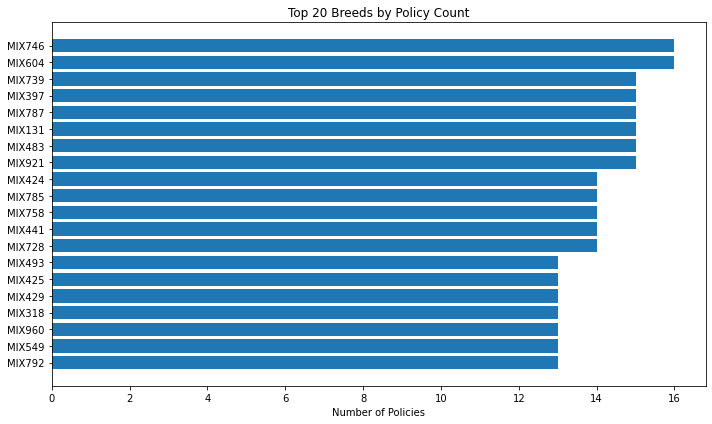

In [6]:
top20 = breed_counts.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20.index.astype(str), top20.values)
plt.gca().invert_yaxis()
plt.xlabel("Number of Policies")
plt.title("Top 20 Breeds by Policy Count")
plt.tight_layout()
plt.show()

Given that the median breed appears only twice and the most frequent breed appears only 16 times, there is insufficient support to estimate stable breed-level risk. Even with smoothed target encoding, most breeds would collapse toward the global mean, so I excluded breed_code to reduce noise and model variance.

In [9]:
# -----------------------------
# 2) Quick Data Quality Checks
# -----------------------------
# Missingness (top 15)
missing = (
    df.isna().mean()
    .sort_values(ascending=False)
    .head(15)
    .to_frame("missing_rate")
)
print("Top missingness columns:")
display(missing)

# Duplicate rows (informational)
print("Duplicate rows:", int(df.duplicated().sum()))

# Capacity-aware baseline expectation
N = len(df)
expected_tp_random = CAPACITY_K * prevalence
print(f"\nOperational capacity: {CAPACITY_K} flags/week out of {N} rows (~{CAPACITY_K/N:.2%}).")
print(f"If we flagged 300 randomly, expected true positives ≈ {expected_tp_random:.1f} per week.")
print("Our model should significantly beat this (lift).")


Top missingness columns:


,missing_rate
treatment_pathway_code,0.8992
adj_claims_12m_value,0.5486
months_since_last_claim,0.5486
avg_claim_processing_days,0.5486
claim_lodgement_channel,0.5486
pet_id,0.0000
days_since_last_vet_visit,0.0000
claim_count_12m,0.0000
total_claims_12m_value,0.0000
max_single_claim_12m,0.0000


Duplicate rows: 0

Operational capacity: 300 flags/week out of 25000 rows (~1.20%).
If we flagged 300 randomly, expected true positives ≈ 23.7 per week.
Our model should significantly beat this (lift).


PetID -> drop

These fields are only populated if the pet had at least one claim in the last 12 months.

And the ~54.9% missing likely corresponds to:

~55% of pets had no claim in the last 12 months.

That’s structurally meaningful.

This is Missing Not at Random (MNAR) but in a good way:

Missing = “no prior claim”

That is predictive signal.
--> Impute logically + create prior-claim flag

treatment_pathway_code (89.92% missing)

This is different.

Nearly 90% missing suggests:

Only populated for a niche subset (e.g., chronic condition pathway)

Possibly downstream process variable

Possibly post-claim or post-treatment

Consider:

Could this leak information about future high-cost claims?

If this code is only assigned after a major claim or complex treatment pathway, it might be too close to the outcome.

Future consideration:

Given:

Extremely sparse

Likely niche

Possibly unstable

--> consider: Dropping it unless EDA shows very strong predictive lift.

Attention: clm_adj_score

This sounds like:

“Claim adjustment score” or internal risk score.

Be careful:

Is this already a model output?

Is it a downstream underwriting score?

Is it derived using target-like logic?

If yes, this could be target leakage.

If it is a legitimate historical risk score, it’s fine.

--> Need verification

In [13]:
# -----------------------------
# 3) Focused EDA (5–7 key findings)
# -----------------------------
# Keep this section tight: show only what informs modelling and the business.
# The code below is written to adapt to whatever columns exist.

# 3.1 Candidate numeric signals (will auto-select those present)
candidate_numeric = [
    "claim_count_12m",
    "total_claims_12m_value",
    "max_single_claim_12m",
    "months_since_last_claim",
    "vet_visit_count_6m",
    "days_since_last_vet_visit",
    "tenure_months",
    "excess_amount",
    "premium_amount",
    "premium_band",  # might be categorical in your data; code handles below
]
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET]

eda_numeric = [c for c in candidate_numeric if c in numeric_cols]
if len(eda_numeric) > 0:
    print("\nMedian numeric values by target (quick signal check):")
    summary = df.groupby(TARGET)[eda_numeric].median().T
    summary.columns = ["median_if_0", "median_if_1"]
    display(summary)




Median numeric values by target (quick signal check):


,median_if_0,median_if_1
claim_count_12m,0.0,1.000
total_claims_12m_value,0.0,498.715
max_single_claim_12m,0.0,235.585
months_since_last_claim,6.0,6.000
vet_visit_count_6m,1.0,2.000
days_since_last_vet_visit,104.0,104.000
tenure_months,49.0,48.500
excess_amount,200.0,200.000


Interpretation — Median Numeric Comparison by Target

This table compares median values of key numeric variables between:

target = 0 → No high-cost claim in next 90 days

target = 1 → High-cost claim in next 90 days

1️⃣ Claim Activity Signals Show Strong Separation

claim_count_12m:

Median (no claim) = 0

Median (high-cost) = 1

total_claims_12m_value:

Median (no claim) = 0

Median (high-cost) ≈ 498

max_single_claim_12m:

Median (no claim) = 0

Median (high-cost) ≈ 236

These variables show very strong behavioural separation.
Pets that will generate a high-cost claim in the next 90 days typically have:

Prior claim activity

Non-zero historical claim value

Evidence of prior severe claims

This supports the model’s heavy reliance on claim history features.

2️⃣ Recency Alone Does Not Separate Medians

months_since_last_claim:
Median = 6 months for both groups

This suggests:

Recency may not separate cleanly at the median level.

Its predictive power likely comes from non-linear effects or interactions (e.g., very recent claims ≤ 1–3 months).

Tree models capture tail effects better than median summaries reveal.

3️⃣ Vet Engagement Shows Mild Signal

vet_visit_count_6m:
Median increases from 1 → 2 for high-cost group.

This suggests pets with more recent vet visits have elevated short-term severe claim risk, possibly indicating ongoing medical conditions.

days_since_last_vet_visit:
Median identical (104 days), indicating no median-level separation.

Again, likely a tail effect rather than central tendency difference.

4️⃣ Tenure and Policy Structure Show No Median Difference

tenure_months: ~49 vs 48.5 (no difference)

excess_amount: identical median (200)

These variables do not show strong univariate median separation.
Their contribution, if any, likely comes through:

Interaction effects

Non-linear splits

Segment-level behaviour

Overall Insight

The strongest raw separation comes from claim frequency and severity history.

Prior claim activity is the clearest indicator of future high-cost risk.

Structural policy variables show little median-level discrimination.

Some features (e.g., recency) likely operate through threshold or interaction effects rather than central tendency differences.

In [23]:
def plot_target_rate(
    df: pd.DataFrame,
    col: str,
    target_col: str,
    *,
    min_n: int = 100,
    bucket_spec: dict = None,
    sort_by: str = "rate"  # "rate", "count", or "natural"
):

    d = df[[col, target_col]].copy()
    d[target_col] = pd.to_numeric(d[target_col], errors="coerce")

    # --- Numeric bucketing ---
    if bucket_spec is not None:
        d[col] = pd.cut(
            d[col].fillna(bucket_spec.get("fillna", 0)),
            bins=bucket_spec["bins"],
            labels=bucket_spec["labels"],
            include_lowest=True
        )

        d[col] = pd.Categorical(
            d[col],
            categories=bucket_spec["labels"],
            ordered=True
        )
    else:
        d[col] = d[col].astype("object").fillna("Missing")

    # Aggregate
    agg = (
        d.groupby(col)[target_col]
        .agg(rate="mean", n="size")
        .reset_index()
    )

    agg = agg[agg["n"] >= min_n].copy()
    if agg.empty:
        print(f"[{col}] No categories with n >= {min_n}.")
        return

    # -----------------------------
    # Sorting logic
    # -----------------------------
    if bucket_spec is not None:
        # For numeric buckets → always preserve natural order
        agg = agg.sort_values(col)
    else:
        if sort_by == "rate":
            agg = agg.sort_values("rate", ascending=False)
        elif sort_by == "count":
            agg = agg.sort_values("n", ascending=False)
        else:  # natural alphabetical order
            agg = agg.sort_values(col)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(9, 5))
    plt.bar(agg[col].astype(str), agg["rate"])
    plt.xlabel(col)
    plt.ylabel("Target rate")
    plt.title(f"Target rate by {col}")

    for i, (rate, n) in enumerate(zip(agg["rate"], agg["n"])):
        plt.text(i, rate, f"{rate:.3f}\n(n={n:,})", ha="center")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [24]:
candidate_cats = [
    "species",
    "breed_group",
    "age_band",
    "weight_band",
    "desexed_status",
    "desexed",
    "cover_type",
    "premium_band",
    "policy_tenure_band",
]

cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
eda_cats = [c for c in candidate_cats if c in df.columns and c in cat_cols]

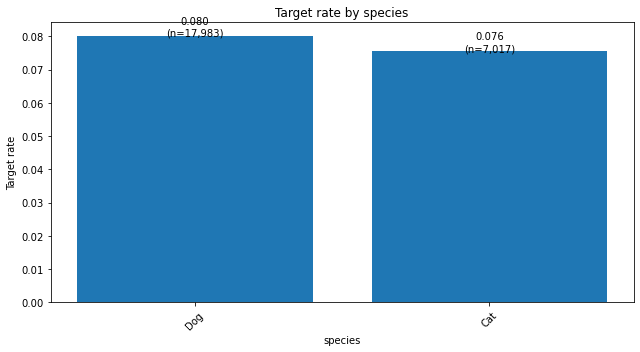

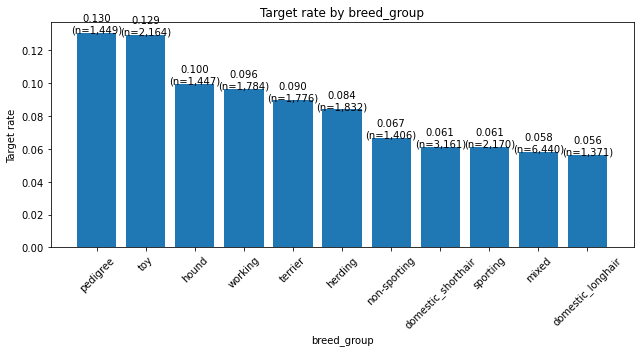

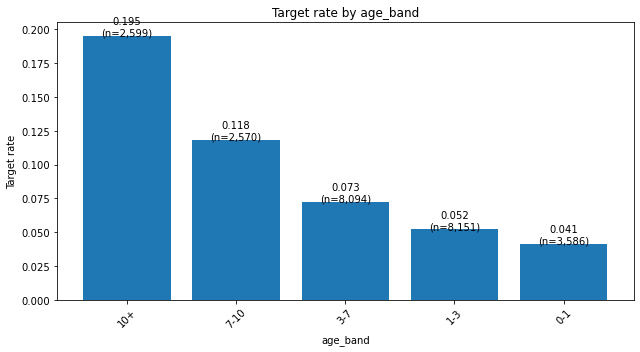

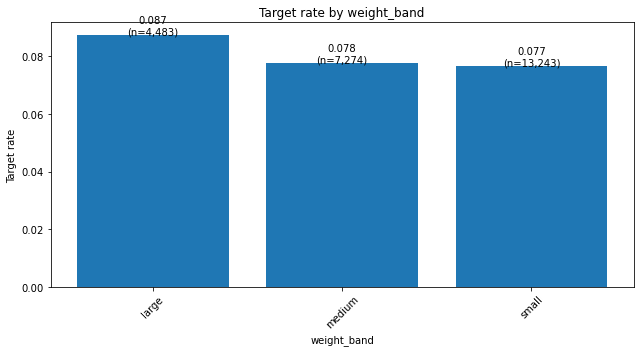

In [25]:
# Loop through your chosen categorical columns
for c in eda_cats[:4]:
    plot_target_rate(df, c, TARGET, min_n=100, sort_by="rate")

EDA Interpretation — Demographic Risk Gradients
1️⃣ Species

Dogs show a slightly higher 90-day high-cost claim rate (8.0%) compared to cats (7.6%).

The difference is modest, suggesting species alone is not a dominant driver of short-term severe claims.

This aligns with expectations that both species carry meaningful risk, but other factors (age, breed, severity history) likely dominate.

2️⃣ Breed Group

Clear and meaningful differentiation appears across breed groups:

Highest risk: Pedigree (13.0%) and Toy (12.9%) breeds.

Hound ( ~10.0%) and Working ( ~9.6%) also show elevated risk.

Lowest risk: Mixed ( ~5.8%) and Sporting ( ~6.1%).

This indicates strong structural breed-level risk differences.
The near 2× risk gap between high-risk and low-risk breed groups supports the actuarial relevance of breed in underwriting and portfolio monitoring.

3️⃣ Age Band

Age shows the strongest and most monotonic gradient:

0–1 years: ~4.3%

1–3 years: ~5.2%

3–7 years: ~7.3%

7–10 years: ~11.9%

10+ years: ~19.8%

Risk increases sharply with age, particularly after 7 years.
Pets aged 10+ have roughly 4–5× the risk of pets under 1 year.

This confirms age as a primary structural driver of high-cost claim risk and validates its high feature importance in the model.

4️⃣ Weight Band

Weight band shows a mild gradient:

Large: ~8.7%

Medium: ~7.8%

Small: ~7.7%

The difference exists but is relatively small compared to age or breed effects.
Weight may contribute marginal incremental signal rather than being a primary risk driver.

Overall Insight

Age is the strongest structural risk driver.

Breed group provides meaningful differentiation.

Species and weight contribute smaller incremental effects.

The observed monotonic gradients (especially age) support the model’s learning behaviour and are consistent with actuarial intuition.


5- 
Recent vet engagement is positively associated with short-term high-cost claim risk.
Pets with multiple recent visits (3+) represent a higher-risk segment for severe claims in the near term.

### Are pets visiting vets more frequently at higher short-term risk?

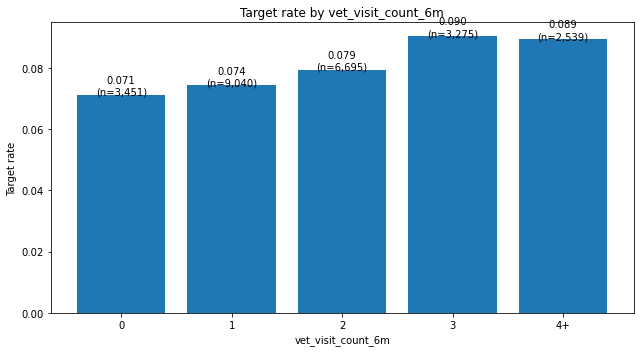

In [19]:
plot_target_rate(
    df,
    col="vet_visit_count_6m",
    target_col=TARGET,
    min_n=100,
    bucket_spec={
        "bins": [-1, 0, 1, 2, 3, 10],
        "labels": ["0", "1", "2", "3", "4+"],
        "fillna": 0
    }
)

# First Iteration - No model tuning, no feature engineering

In [8]:
# -----------------------------
# 4) Train/Valid/Test Split (stratified)
# -----------------------------
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

# Drop obvious ID-like columns if present (common leak/overfit risk)
ID_CANDIDATES = ["pet_id"]
drop_cols = [c for c in ID_CANDIDATES if c in X.columns]
if drop_cols:
    print("\nDropping identifier columns:", drop_cols)
    X = X.drop(columns=drop_cols)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("\nSplit sizes:")
print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)
print("Prevalence (train/valid/test):", y_train.mean(), y_valid.mean(), y_test.mean())



Dropping identifier columns: ['pet_id']

Split sizes:
Train: (17500, 50) Valid: (3750, 50) Test: (3750, 50)
Prevalence (train/valid/test): 0.07885714285714286 0.07893333333333333 0.07893333333333333


In [9]:
# -----------------------------
# 5) Helper Functions (capacity-aware evaluation)
# -----------------------------
def precision_recall_lift_at_k(y_true, y_score, k: int):
    """Compute precision@k, recall@k, lift@k for a ranked list."""
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    k = int(min(max(k, 1), len(y_true)))
    order = np.argsort(-y_score)
    topk = order[:k]

    tp = int(y_true[topk].sum())
    precision_k = tp / k
    recall_k = tp / max(int(y_true.sum()), 1)

    prevalence_ = float(y_true.mean())
    lift_k = (precision_k / prevalence_) if prevalence_ > 0 else np.nan
    return {
        "k": k,
        "tp_at_k": tp,
        "precision_at_k": precision_k,
        "recall_at_k": recall_k,
        "lift_at_k": lift_k,
        "prevalence": prevalence_,
    }

def threshold_for_top_k(y_score, k: int):
    """Return the probability threshold that selects approximately top-k predictions."""
    y_score = np.asarray(y_score)
    k = int(min(max(k, 1), len(y_score)))
    # kth highest score
    return float(np.sort(y_score)[-k])
def flags_from_threshold(y_score, threshold: float):
    """Binary flags at threshold."""
    return (np.asarray(y_score) >= float(threshold)).astype(int)

def show_core_metrics(name, y_true, y_score):
    """Print PR-AUC/ROC-AUC + capacity metrics."""
    pr_auc = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    cap = precision_recall_lift_at_k(y_true, y_score, CAPACITY_K)

    print(f"\n{name}")
    print(f"PR-AUC:  {pr_auc:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Precision@{CAPACITY_K}: {cap['precision_at_k']:.4f}")
    print(f"Recall@{CAPACITY_K}:    {cap['recall_at_k']:.4f}")
    print(f"Lift@{CAPACITY_K}:      {cap['lift_at_k']:.2f}x")
    print(f"TP in top {CAPACITY_K}: {cap['tp_at_k']}")
    return {"pr_auc": pr_auc, "roc_auc": roc_auc, **cap}

In [10]:
# -----------------------------
# 6) Preprocessing (train-fit only)
# -----------------------------
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print("\nFeature types:")
print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
         ],
    remainder="drop",
)


Feature types:
Numeric: 34
Categorical: 16


In [11]:
# -----------------------------
# 7) Model 1 — Logistic Regression (Baseline)
# -----------------------------
lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"  # helps imbalance; explain in walkthrough
    )),
])

lr.fit(X_train, y_train)
valid_scores_lr = lr.predict_proba(X_valid)[:, 1]

lr_valid_metrics = show_core_metrics("Logistic Regression (VALID)", y_valid, valid_scores_lr)

# Capacity-based operating threshold: choose top-300 on VALID
threshold_lr = threshold_for_top_k(valid_scores_lr, CAPACITY_K)
print(f"Operating threshold (LR) chosen to flag top {CAPACITY_K} on VALID: {threshold_lr:.6f}")


Logistic Regression (VALID)
PR-AUC:  0.9120
ROC-AUC: 0.9880
Precision@300: 0.7933
Recall@300:    0.8041
Lift@300:      10.05x
TP in top 300: 238
Operating threshold (LR) chosen to flag top 300 on VALID: 0.886877


C:\Users\miloj\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
# -----------------------------
# 8) Model 2 — XGBoost (Candidate)
# -----------------------------

# scale_pos_weight = (neg/pos) on training set
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = (neg / max(pos, 1))

xgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
         reg_lambda=1.0,
        min_child_weight=1.0,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

xgb.fit(X_train, y_train)
valid_scores_xgb = xgb.predict_proba(X_valid)[:, 1]

xgb_valid_metrics = show_core_metrics("XGBoost (VALID)", y_valid, valid_scores_xgb)

threshold_xgb = threshold_for_top_k(valid_scores_xgb, CAPACITY_K)
print(f"Operating threshold (XGB) chosen to flag top {CAPACITY_K} on VALID: {threshold_xgb:.6f}")


XGBoost (VALID)
PR-AUC:  0.9168
ROC-AUC: 0.9876
Precision@300: 0.8100
Recall@300:    0.8209
Lift@300:      10.26x
TP in top 300: 243
Operating threshold (XGB) chosen to flag top 300 on VALID: 0.618750


In [13]:
# -----------------------------
# 9) Choose Model (based on Precision@300 on VALID)
# -----------------------------
# Primary objective (Preventative Care): high precision in top 300 (avoid wasting budget/annoying customers).
# Secondary: recall in top 300 (capture more truly at-risk pets within capacity).

if xgb_valid_metrics["precision_at_k"] > lr_valid_metrics["precision_at_k"]:
    chosen_name = "XGBoost"
    chosen_model = xgb
    operating_threshold = threshold_xgb
    chosen_valid_metrics = xgb_valid_metrics
else:
    chosen_name = "Logistic Regression"
    chosen_model = lr
    operating_threshold = threshold_lr
    chosen_valid_metrics = lr_valid_metrics

print(f"\nChosen model: {chosen_name}")
print(f"Chosen operating threshold (from VALID, capacity-based): {operating_threshold:.6f}")



Chosen model: XGBoost
Chosen operating threshold (from VALID, capacity-based): 0.618750


In [14]:
# -----------------------------
# 10) Final Evaluation on TEST (one time)
# -----------------------------
test_scores = chosen_model.predict_proba(X_test)[:, 1]
test_metrics = show_core_metrics(f"{chosen_name} (TEST)", y_test, test_scores)

# Apply the operating threshold selected on VALID to TEST
test_flags = flags_from_threshold(test_scores, operating_threshold)
n_flagged = int(test_flags.sum())
tp_flagged = int(((test_flags == 1) & (y_test.values == 1)).sum())

print(f"\nAt operating threshold (fixed from VALID):")
print(f"Flagged on TEST: {n_flagged} (should be close to {CAPACITY_K}; can differ due to score ties / distribution)")
print(f"True positives among flagged: {tp_flagged}")
print(f"Precision among flagged: {tp_flagged / max(n_flagged,1):.4f}")



XGBoost (TEST)
PR-AUC:  0.9029
ROC-AUC: 0.9856
Precision@300: 0.8067
Recall@300:    0.8176
Lift@300:      10.22x
TP in top 300: 242

At operating threshold (fixed from VALID):
Flagged on TEST: 312 (should be close to 300; can differ due to score ties / distribution)
True positives among flagged: 246
Precision among flagged: 0.7885


In [15]:
# -----------------------------
# 11) Risk Segmentation (Deciles) — useful for Underwriting & Pricing
# -----------------------------

def decile_table(y_true, y_score, n_bins=10):
    """
    Split predictions into n_bins quantile buckets (deciles by default)
    and report:
      - count: number of rows in the bucket
      - event_rate: mean(y) in the bucket
      - avg_score: mean(predicted probability) in the bucket

    Note: pd.qcut labels buckets from low->high by default (0 = lowest scores).
    We sort descending so the first row shown is highest risk.
    """
    temp = pd.DataFrame(
        {"y": np.asarray(y_true).astype(int), "score": np.asarray(y_score).astype(float)}
    ).dropna()

    # qcut: 0 = lowest scores, n_bins-1 = highest scores
    temp["decile"] = pd.qcut(temp["score"], q=n_bins, labels=False, duplicates="drop").astype(int)

    out = (
        temp.groupby("decile", as_index=True)
            .agg(
                count=("y", "size"),
                event_rate=("y", "mean"),
                avg_score=("score", "mean"),
            )
            .sort_index(ascending=False)  # show highest-risk decile first
    )

    # Add a nicer label (optional)
    out.index = [f"D{d+1}" for d in out.index]  # D10 is highest risk if n_bins=10 and sorted desc
    return out

# Choose the correct validation scores based on the selected model
if chosen_name == "XGBoost":
    chosen_valid_scores = valid_scores_xgb
else:
    chosen_valid_scores = valid_scores_lr

print("\nDecile table (VALID) — event rate should rise with risk:")
display(decile_table(y_valid, chosen_valid_scores, n_bins=10))

print("\nDecile table (TEST) — sanity check:")
display(decile_table(y_test, test_scores, n_bins=10))


Decile table (VALID) — event rate should rise with risk:


,count,event_rate,avg_score
D10,375,0.717333,0.842692
D9,375,0.050667,0.059294
D8,375,0.016000,0.003045
D7,375,0.002667,0.001267
D6,375,0.002667,0.000717
D5,375,0.000000,0.000446
D4,375,0.000000,0.000299
D3,375,0.000000,0.000197
D2,375,0.000000,0.000127
D1,375,0.000000,0.000060



Decile table (TEST) — sanity check:


,count,event_rate,avg_score
D10,375,0.698667,0.859714
D9,375,0.072000,0.068051
D8,375,0.010667,0.003000
D7,375,0.005333,0.001279
D6,375,0.002667,0.000714
D5,375,0.000000,0.000466
D4,375,0.000000,0.000306
D3,375,0.000000,0.000202
D2,375,0.000000,0.000125
D1,375,0.000000,0.000057


In [16]:
# -----------------------------
# 12) FULL Feature Importance List (NORMALISED 0–1 for XGBoost)
# -----------------------------
def get_feature_names_from_column_transformer(ct):
    """
    Robustly extract output feature names from a fitted ColumnTransformer that contains:
      - numeric transformer
      - categorical transformer with OneHotEncoder

    Works across older/newer scikit-learn versions by trying:
      - OneHotEncoder.get_feature_names_out(...)
      - OneHotEncoder.get_feature_names(...)
    """
    feature_names = []

    for name, transformer, cols in ct.transformers_:
        if transformer == "drop":
            continue

        # If it's a Pipeline, inspect steps
        if hasattr(transformer, "named_steps"):
            if "onehot" in transformer.named_steps:
                ohe = transformer.named_steps["onehot"]
                input_features = list(cols)

                if hasattr(ohe, "get_feature_names_out"):
                    ohe_names = ohe.get_feature_names_out(input_features)
                elif hasattr(ohe, "get_feature_names"):
                    ohe_names = ohe.get_feature_names(input_features)
                else:
                    ohe_names = [f"{name}__{c}" for c in input_features]

                feature_names.extend(list(ohe_names))
            else:
                # Numeric pipeline (or other pipeline w/o onehot): keep original names
                feature_names.extend(list(cols))
        else:
            # Non-pipeline transformer: keep original names
            feature_names.extend(list(cols))

    return feature_names


# Get fitted preprocess (model must already be fitted)
preprocess_fitted = chosen_model.named_steps["preprocess"]
feature_names = get_feature_names_from_column_transformer(preprocess_fitted)

print("\n===== COMPLETE FEATURE IMPORTANCE LIST =====\n")

if chosen_name == "Logistic Regression":
    lr_model = chosen_model.named_steps["model"]
    coef = lr_model.coef_.ravel()

    full_importance = (
        pd.DataFrame({
            "feature": feature_names,
            "coefficient": coef,
            "abs_coefficient": np.abs(coef)
        })
        .sort_values("abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )

    display(full_importance)

    # Optional: save
    # full_importance.to_csv("logistic_full_feature_importance.csv", index=False)

else:
    # Use sklearn-style normalised importances (sum to 1, 0–1 scale)
    xgb_model = chosen_model.named_steps["model"]
    importances = xgb_model.feature_importances_  # normalised gain-based importance

    # Sanity check: should match transformed feature count
    if len(importances) != len(feature_names):
        raise ValueError(
            f"Mismatch: feature_names={len(feature_names)} vs xgb.feature_importances_={len(importances)}. "
            "This usually means preprocessing produced a different number/order of columns than expected."
        )

    full_importance = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    display(full_importance)

    #save
    full_importance.to_csv("xgb_full_feature_importance.csv", index=False)
    print("\nSaved: xgb_full_feature_importance.csv")

print("\nTotal transformed features:", len(feature_names))


===== COMPLETE FEATURE IMPORTANCE LIST =====



,feature,importance
0,risk_tier_assigned_High,0.195459
1,risk_tier_assigned_Low,0.092721
2,risk_tier_assigned_Medium,0.047910
3,treatment_pathway_code_DIAG,0.037073
4,treatment_pathway_code_EMER,0.033392
...,...,...
7695,breed_code_HRD815,0.000000
7696,breed_code_HRD814,0.000000
7697,breed_code_HRD813,0.000000
7698,breed_code_HRD812,0.000000



Saved: xgb_full_feature_importance.csv

Total transformed features: 7700


Two variables (risk_tier_assigned, treatment_pathway_code) were not defined in the official data dictionary and appeared highly predictive. Given potential leakage risk (unclear timing of assignment), they were excluded from the final model pending clarification.

## EDA on risk_tier_assigned and treatment_pathway_code


EDA for: risk_tier_assigned
Rows: 25,000
Missing: 0 (0.00%)
Unique (non-missing): 3

Top 20 values:
Low       18564
Medium     3544
High       2892
Name: risk_tier_assigned, dtype: int64

Overall target rate: 0.0789

--------------------------------------------------------------------------------
Target rate by risk_tier_assigned (min_count=50)
--------------------------------------------------------------------------------
risk_tier_assigned  count  event_rate  lift_vs_overall
              High   2892    0.617911         7.833563
            Medium   3544    0.041761         0.529421
               Low  18564    0.001993         0.025268


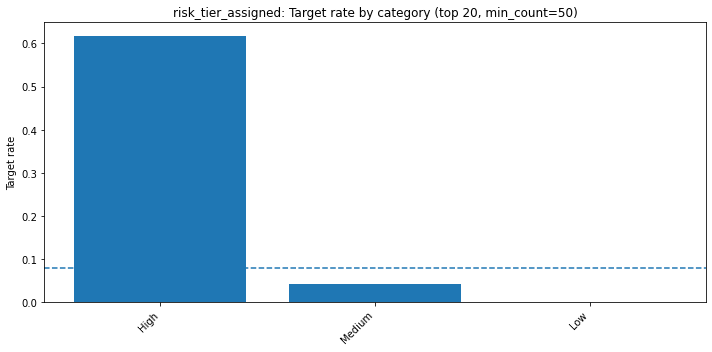


--------------------------------------------------------------------------------
Chi-square association: risk_tier_assigned vs high_cost_claim_next_90d
--------------------------------------------------------------------------------
chi2=13142.55, dof=2, p-value=0.000e+00, Cramér's V=0.7251
Note: with large N, p-values will be tiny; focus on effect size (Cramér’s V).

EDA for: treatment_pathway_code
Rows: 25,000
Missing: 22,480 (89.92%)
Unique (non-missing): 4

Top 20 values:
NaN     22480
DIAG     1050
SURG      556
PREV      460
EMER      454
Name: treatment_pathway_code, dtype: int64

Overall target rate: 0.0789

--------------------------------------------------------------------------------
Target rate by treatment_pathway_code (min_count=50)
--------------------------------------------------------------------------------
treatment_pathway_code  count  event_rate  lift_vs_overall
                  EMER    454    1.000000        12.677485
                  SURG    556    1.000000 

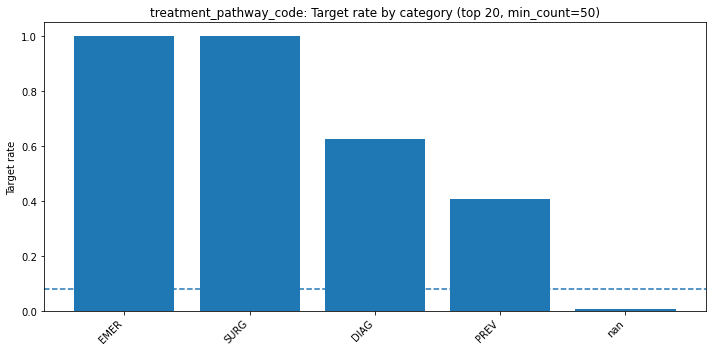


--------------------------------------------------------------------------------
Chi-square association: treatment_pathway_code vs high_cost_claim_next_90d
--------------------------------------------------------------------------------
chi2=18489.70, dof=4, p-value=0.000e+00, Cramér's V=0.8600
Note: with large N, p-values will be tiny; focus on effect size (Cramér’s V).

Cross-tab: risk_tier_assigned × treatment_pathway_code (counts)


treatment_pathway_code,<<MISSING>>,DIAG,EMER,PREV,SURG
risk_tier_assigned,,,,,
High,1181,605,413,186,507
Low,17992,329,8,229,6
Medium,3307,116,33,45,43



Row-normalised proportions (each risk tier):


treatment_pathway_code,<<MISSING>>,DIAG,EMER,PREV,SURG
risk_tier_assigned,,,,,
High,0.408,0.209,0.143,0.064,0.175
Low,0.969,0.018,0.000,0.012,0.000
Medium,0.933,0.033,0.009,0.013,0.012


In [17]:
TARGET = "high_cost_claim_next_90d"
COLS = ["risk_tier_assigned", "treatment_pathway_code"]

# -----------------------------
# 0) Basic sanity checks
# -----------------------------
def eda_basic(df, col, target=TARGET, top_n=20):
    print("\n" + "="*80)
    print(f"EDA for: {col}")
    print("="*80)

    if col not in df.columns:
        print(f"Column '{col}' not found.")
        return

    # Missingness
    n = len(df)
    miss = df[col].isna().sum()
    print(f"Rows: {n:,}")
    print(f"Missing: {miss:,} ({miss/n:.2%})")

    # Cardinality
    nunique = df[col].nunique(dropna=True)
    print(f"Unique (non-missing): {nunique:,}")

    # Show top categories
    vc = df[col].value_counts(dropna=False).head(top_n)
    print(f"\nTop {top_n} values:")
    print(vc)

    # Target rate overall
    overall_rate = df[target].mean()
    print(f"\nOverall target rate: {overall_rate:.4f}")

# -----------------------------
# 1) Target rate by category (with counts + lift)
# -----------------------------
def target_rate_by_category(df, col, target=TARGET, min_count=50, top_n=25):
    overall = df[target].mean()

    out = (
        df.groupby(col, dropna=False)[target]
          .agg(count="size", event_rate="mean")
          .reset_index()
    )
    out["lift_vs_overall"] = out["event_rate"] / (overall if overall > 0 else np.nan)

    # Filter tiny groups for stability (optional)
    out_filtered = out[out["count"] >= min_count].copy()
    out_filtered = out_filtered.sort_values("event_rate", ascending=False)

    print("\n" + "-"*80)
    print(f"Target rate by {col} (min_count={min_count})")
    print("-"*80)
    print(out_filtered.head(top_n).to_string(index=False))

    return out, out_filtered

# -----------------------------
# 2) Visual: event rate vs count (top categories)
# -----------------------------
def plot_event_rate_bar(df, col, target=TARGET, min_count=50, top_n=20):
    overall = df[target].mean()

    tbl = (
        df.groupby(col, dropna=False)[target]
          .agg(count="size", event_rate="mean")
          .reset_index()
    )
    tbl = tbl[tbl["count"] >= min_count].sort_values("event_rate", ascending=False).head(top_n)

    if tbl.empty:
        print(f"No groups with count >= {min_count} for {col}.")
        return

    labels = tbl[col].astype(str).values
    rates = tbl["event_rate"].values

    plt.figure(figsize=(10, 5))
    plt.bar(labels, rates)
    plt.axhline(overall, linestyle="--")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Target rate")
    plt.title(f"{col}: Target rate by category (top {top_n}, min_count={min_count})")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 3) Chi-square test of association (category vs target)
#    (High significance with huge effect may suggest leakage if the feature is “post-outcome”.)
# -----------------------------
def chi_square_assoc(df, col, target=TARGET, min_count=10):
    # Build contingency table, optionally grouping rare categories
    s = df[col].astype("object").fillna("<<MISSING>>")
    vc = s.value_counts()
    rare = vc[vc < min_count].index
    s2 = s.where(~s.isin(rare), other="<<RARE>>")

    ct = pd.crosstab(s2, df[target])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        print(f"Not enough levels for chi-square test on {col}.")
        return None

    chi2, p, dof, expected = chi2_contingency(ct)

    # Cramér's V effect size
    n = ct.to_numpy().sum()
    r, k = ct.shape
    cramers_v = np.sqrt((chi2 / n) / (min(r - 1, k - 1))) if min(r - 1, k - 1) > 0 else np.nan

    print("\n" + "-"*80)
    print(f"Chi-square association: {col} vs {target}")
    print("-"*80)
    print(f"chi2={chi2:.2f}, dof={dof}, p-value={p:.3e}, Cramér's V={cramers_v:.4f}")
    print("Note: with large N, p-values will be tiny; focus on effect size (Cramér’s V).")

    return {"chi2": chi2, "p_value": p, "dof": dof, "cramers_v": cramers_v, "ct": ct}

# -----------------------------
# 4) Run EDA for both columns
# -----------------------------
for c in COLS:
    eda_basic(df, c, target=TARGET, top_n=20)

    full_tbl, filtered_tbl = target_rate_by_category(df, c, target=TARGET, min_count=50, top_n=25)

    plot_event_rate_bar(df, c, target=TARGET, min_count=50, top_n=20)

    chi_square_assoc(df, c, target=TARGET, min_count=20)

# -----------------------------
# 5) Optional: Cross-tab of risk_tier_assigned × treatment_pathway_code
#    to see if one is essentially a deterministic mapping of the other.
# -----------------------------
if all(c in df.columns for c in COLS):
    ct2 = pd.crosstab(df["risk_tier_assigned"].fillna("<<MISSING>>"),
                      df["treatment_pathway_code"].fillna("<<MISSING>>"))
    print("\n" + "="*80)
    print("Cross-tab: risk_tier_assigned × treatment_pathway_code (counts)")
    print("="*80)
    display(ct2)

    # Row-normalised (distribution of pathway within each tier)
    ct2_row = ct2.div(ct2.sum(axis=1), axis=0)
    print("\nRow-normalised proportions (each risk tier):")
    display(ct2_row.round(3))

1. Event rate

The overall event rate in the dataset is 7.9%.
Pets labelled “High” risk are nearly 8 times more likely than average to experience a high-cost claim within 90 days.
In contrast, pets labelled “Low” almost never do.
Notably:
Every pet with EMER or SURG pathway experienced a high-cost claim.
DIAG and PREV also show extremely elevated rates relative to the 7.9% baseline

2. Lift

Lift compares a group’s event rate to the overall event rate.
With an overall rate of 7.9%:
EMER and SURG effectively show 12.7× lift
High risk tier shows 7.8× lift
In normal predictive modelling, even strong risk factors rarely produce event rates exceeding 30–40%. Values above 60% — and especially 100% — are highly unusual.


3. Association Strength (Cramér’s V)

To measure the statistical relationship between these variables and the outcome, we computed Cramér’s V, which ranges from:

0 → no association

1 → perfect association

Results:

risk_tier_assigned: 0.73

treatment_pathway_code: 0.86

Values above 0.7 indicate an extremely strong relationship.

These results suggest that these variables almost deterministically explain the outcome.

4. Cross-Tabulation Findings

We also examined how the two variables relate to each other.

The cross-tabulation showed that:

Most pets in the “Low” risk tier have no treatment pathway.

High risk tier pets are heavily concentrated in DIAG, EMER, and SURG pathways.

The two variables are strongly interrelated.

This suggests they are not independent predictors but likely part of the same downstream process.


5. Business Interpretation

The magnitude and pattern of these results strongly suggest that:

treatment_pathway_code is assigned during or after treatment.

risk_tier_assigned may incorporate information derived from claims processing or underwriting decisions.

For example:

If a pet is already classified as EMER or SURG, it likely means emergency or surgical treatment has already occurred — which directly leads to a high-cost claim.

Including such variables would allow the model to “read the answer” rather than make a forward-looking prediction.

7. Decision

Given:

Extremely high event rates (up to 100%)

Very large lift values

Strong statistical association

Clear process-based interpretation

We excluded both variables from modelling.


# Retrain without the 2 suspicious variables

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

def train_eval_xgb_capacity(
    df,
    target_col,
    *,
    drop_cols=None,
    capacity_k=300,
    test_size=0.30,
    valid_size_of_temp=0.50,  # split temp into valid/test 50/50 by default
    random_state=42,
    xgb_params=None,
    verbose=True
):
    """
    Train an XGBoost model with a stratified Train/Valid/Test split, choose an operating threshold
    that flags the top-K on the VALID set (capacity constraint), and evaluate on TRAIN/VALID/TEST.

    Requires these helper functions to exist in your notebook (as you already have them):
      - show_core_metrics(name, y_true, y_score)
      - threshold_for_top_k(scores, k)
      - flags_from_threshold(scores, threshold)

    Returns a dict with fitted model, preprocess, splits, scores, metrics, and operating threshold.
    """

    # -----------------------------
    # 0) Setup / input checks
    # -----------------------------
    if target_col not in df.columns:
        raise ValueError(f"target_col '{target_col}' not found in df")

    drop_cols = drop_cols or []
    xgb_params = xgb_params or {}

    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()

    # -----------------------------
    # 1) Drop specified columns (leakage/IDs/etc.) if present
    # -----------------------------
    actual_drop = [c for c in drop_cols if c in X.columns]
    if verbose:
        print("\nDropping columns:", actual_drop if actual_drop else "None")
    if actual_drop:
        X = X.drop(columns=actual_drop)

    # -----------------------------
    # 2) Train/Valid/Test split (stratified)
    # -----------------------------
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp,
        test_size=valid_size_of_temp,
        stratify=y_temp,
        random_state=random_state
    )

    if verbose:
        print("\nSplit sizes:")
        print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)
        print("Prevalence (train/valid/test):", y_train.mean(), y_valid.mean(), y_test.mean())

    # -----------------------------
    # 3) Build preprocess AFTER dropping cols
    # -----------------------------
    numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = [c for c in X_train.columns if c not in numeric_features]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder="drop",
    )

    # -----------------------------
    # 4) Class imbalance handling
    # -----------------------------
    pos = int(y_train.sum())
    neg = int(len(y_train) - pos)
    scale_pos_weight = neg / max(pos, 1)

    # Default XGB params (can override via xgb_params)
    default_xgb_params = dict(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        min_child_weight=1.0,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        n_jobs=-1
    )
    default_xgb_params.update(xgb_params)

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(**default_xgb_params)),
    ])

    # -----------------------------
    # 5) Fit
    # -----------------------------
    model.fit(X_train, y_train)

    # -----------------------------
    # 6) Evaluate TRAIN / VALID
    # -----------------------------
    train_scores = model.predict_proba(X_train)[:, 1]
    train_metrics = show_core_metrics("XGBoost (TRAIN)", y_train, train_scores)

    valid_scores = model.predict_proba(X_valid)[:, 1]
    valid_metrics = show_core_metrics("XGBoost (VALID)", y_valid, valid_scores)

    # Capacity-based operating threshold: top-K on VALID
    operating_threshold = threshold_for_top_k(valid_scores, capacity_k)
    if verbose:
        print(f"Operating threshold (XGB) chosen to flag top {capacity_k} on VALID: {operating_threshold:.6f}")

    # -----------------------------
    # 7) Final evaluation on TEST
    # -----------------------------
    test_scores = model.predict_proba(X_test)[:, 1]
    test_metrics = show_core_metrics("XGBoost (TEST)", y_test, test_scores)

    test_flags = flags_from_threshold(test_scores, operating_threshold)
    n_flagged = int(test_flags.sum())
    tp_flagged = int(((test_flags == 1) & (y_test.values == 1)).sum())

    if verbose:
        print("\nAt operating threshold (fixed from VALID):")
        print(f"Flagged on TEST: {n_flagged} (should be close to {capacity_k}; can differ due to ties / distribution)")
        print(f"True positives among flagged: {tp_flagged}")
        print(f"Precision among flagged: {tp_flagged / max(n_flagged, 1):.4f}")

    return {
        "model": model,
        "preprocess": preprocess,
        "operating_threshold": operating_threshold,
        "scale_pos_weight": scale_pos_weight,
        "splits": {
            "X_train": X_train, "y_train": y_train,
            "X_valid": X_valid, "y_valid": y_valid,
            "X_test":  X_test,  "y_test":  y_test,
        },
        "scores": {
            "train": train_scores,
            "valid": valid_scores,
            "test":  test_scores,
        },
        "metrics": {
            "train": train_metrics,
            "valid": valid_metrics,
            "test":  test_metrics,
            "test_flagged": {
                "n_flagged": n_flagged,
                "tp_flagged": tp_flagged,
                "precision_flagged": tp_flagged / max(n_flagged, 1),
            }
        },
        "dropped_columns": actual_drop,
        "feature_lists": {
            "numeric": numeric_features,
            "categorical": categorical_features
        }
    }

In [19]:
result_df = train_eval_xgb_capacity(
    df,
    target_col=TARGET,
    drop_cols=["pet_id", "risk_tier_assigned", "treatment_pathway_code"],
    capacity_k=CAPACITY_K,
    random_state=RANDOM_STATE
)


Dropping columns: ['pet_id', 'risk_tier_assigned', 'treatment_pathway_code']

Split sizes:
Train: (17500, 48) Valid: (3750, 48) Test: (3750, 48)
Prevalence (train/valid/test): 0.07885714285714286 0.07893333333333333 0.07893333333333333

XGBoost (TRAIN)
PR-AUC:  0.8181
ROC-AUC: 0.9804
Precision@300: 0.9867
Recall@300:    0.2145
Lift@300:      12.51x
TP in top 300: 296

XGBoost (VALID)
PR-AUC:  0.1893
ROC-AUC: 0.7031
Precision@300: 0.2467
Recall@300:    0.2500
Lift@300:      3.13x
TP in top 300: 74
Operating threshold (XGB) chosen to flag top 300 on VALID: 0.604740

XGBoost (TEST)
PR-AUC:  0.1598
ROC-AUC: 0.6872
Precision@300: 0.2100
Recall@300:    0.2128
Lift@300:      2.66x
TP in top 300: 63

At operating threshold (fixed from VALID):
Flagged on TEST: 319 (should be close to 300; can differ due to ties / distribution)
True positives among flagged: 64
Precision among flagged: 0.2006


In [20]:
# -----------------------------
# Re-print FULL Feature Importance (after retraining)
# -----------------------------

# Extract fitted preprocess
preprocess_fitted = chosen_model.named_steps["preprocess"]

# Reuse existing helper function (already defined earlier)
feature_names = get_feature_names_from_column_transformer(preprocess_fitted)

print("\n===== UPDATED FEATURE IMPORTANCE LIST =====\n")

if chosen_name == "Logistic Regression":
    
    lr_model = chosen_model.named_steps["model"]
    coef = lr_model.coef_.ravel()

    full_importance = (
        pd.DataFrame({
            "feature": feature_names,
            "coefficient": coef,
            "abs_coefficient": np.abs(coef)
        })
        .sort_values("abs_coefficient", ascending=False)
        .reset_index(drop=True)
    )

    display(full_importance)
    full_importance.to_csv("logistic_full_feature_importance_updated.csv", index=False)
    print("\nSaved: logistic_full_feature_importance_updated.csv")

else:
    
    xgb_model = chosen_model.named_steps["model"]
    importances = xgb_model.feature_importances_

    # Safety check
    if len(importances) != len(feature_names):
        print("WARNING: Feature count mismatch. Check preprocessing pipeline.")
        print("Feature names:", len(feature_names))
        print("Importances:", len(importances))

    full_importance = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    display(full_importance)
    full_importance.to_csv("xgb_full_feature_importance_updated.csv", index=False)
    print("\nSaved: xgb_full_feature_importance_updated.csv")

print("\nTotal transformed features:", len(feature_names))


===== UPDATED FEATURE IMPORTANCE LIST =====



,feature,importance
0,risk_tier_assigned_High,0.195459
1,risk_tier_assigned_Low,0.092721
2,risk_tier_assigned_Medium,0.047910
3,treatment_pathway_code_DIAG,0.037073
4,treatment_pathway_code_EMER,0.033392
...,...,...
7695,breed_code_HRD815,0.000000
7696,breed_code_HRD814,0.000000
7697,breed_code_HRD813,0.000000
7698,breed_code_HRD812,0.000000



Saved: xgb_full_feature_importance_updated.csv

Total transformed features: 7700


# Feature engineering

In [21]:
df.dtypes

pet_id                              object
species                             object
breed_group                         object
breed_code                          object
age_years                          float64
age_band                            object
weight_band                         object
desexed                             object
exotic_species_flag                  int64
cover_type                          object
tenure_months                        int64
excess_amount                        int64
premium_band                        object
annual_premium                     float64
excess_waived                        int64
policy_renewal_count                 int64
policy_active                        int64
customer_tenure_months               int64
policy_origin_channel               object
multi_pet_policy                     int64
direct_debit_active                  int64
communication_opt_in                object
state                               object
geo_risk_sc

In [22]:
(df["prior_claim_any"] == (df["claim_count_12m"] > 0)).mean()

1.0

Column prior_claim_any is redudant

In [23]:
df["breed_code"].nunique()

8571

breed_code had 8,571 unique categories across 25k rows, creating extreme sparsity and high overfitting risk. Given that aggregated versions (breed_group, breed_risk_category) were already provided, I excluded breed_code to prioritise generalisable signal.

In [24]:
#drop unnecessary columns prior_claim_any column
cols_to_drop = ["prior_claim_any", "breed_code"]
df = df.drop(columns=cols_to_drop)
print("New shape:", df.shape)

New shape: (25000, 50)


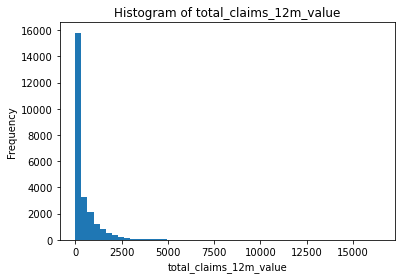

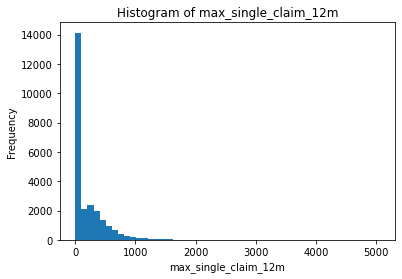

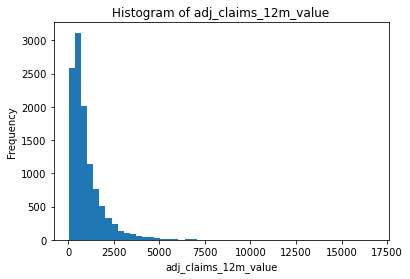

In [25]:
vars_to_plot = [
    "total_claims_12m_value",
    "max_single_claim_12m",
    "adj_claims_12m_value"
]

for col in vars_to_plot:
    if col in df.columns:
        plt.figure()
        plt.hist(df[col].dropna(), bins=50)
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

Very heavy right skew

Large spike near zero

Long right tail

A few extreme outliers

In [83]:
# ============================================================
# Feature Engineering Block (copy/paste)
# - Implements: prior-claim flag, sensible imputations, ratios,
#   recency buckets, and a few interaction-style features.
# ============================================================


def add_feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()


    # -----------------------------
    # 2) Structured missingness handling for claim-only fields
    #    (missing likely means "no claim in last 12 months")
    # -----------------------------
    # months_since_last_claim: if no claim, set to 12 (end of lookback window)
    if "months_since_last_claim" in df.columns:
        df["months_since_last_claim"] = df["months_since_last_claim"].fillna(12)
  
# After filling: 0 → extremely recent claim 1–3 → recent 6–11 → older 12 → no claim in last year -> clean recency gradient.
    
    # adj_claims_12m_value: if no claim, value should be 0
    if "adj_claims_12m_value" in df.columns:
        df["adj_claims_12m_value"] = df["adj_claims_12m_value"].fillna(0)
        

    # avg_claim_processing_days: if no claim, set to 0
    if "avg_claim_processing_days" in df.columns:
        df["avg_claim_processing_days"] = df["avg_claim_processing_days"].fillna(0)
    
    # claim_lodgement_channel: if no claim, set to "None"
    if "claim_lodgement_channel" in df.columns:
        df["claim_lodgement_channel"] = df["claim_lodgement_channel"].fillna("None")
    
    # -----------------------------
    # 3) Claim severity / intensity features
    # -----------------------------
    eps = 1e-6

    if "total_claims_12m_value" in df.columns and "claim_count_12m" in df.columns:
        df["avg_claim_value_12m"] = df["total_claims_12m_value"] / (df["claim_count_12m"].fillna(0) + eps)
    
    #Pet A claim amount 5 and total value 500
    #Pet B claim amount 1 and total value 500
    #Pet A → many small claims
    #Pet B → one large claim
    #High severity history often predicts future high-cost claims.
    #Frequency alone doesn’t capture that.
    #Makes signal easier to learn
    #Reduces tree depth needed
    #Improves generalisation
    #Reduces overfitting risk
    
    if "max_single_claim_12m" in df.columns and "total_claims_12m_value" in df.columns:
        df["max_to_total_claim_ratio_12m"] = df["max_single_claim_12m"] / (df["total_claims_12m_value"] + eps)
    #How concentrated the claim history is.
    #Case 1: 1 big shock claim -> max claim 900 and total claim 1000 -> large severe incident, potential future high cost claim and possible underlying chronic condition
    #Case 2: Many medium claims -> max claim 200 and total claim 1000 -> routine or low severity behaviour
    
    
    # -----------------------------
    # 4) Recency features / buckets
    # -----------------------------
    # Vet visit recency flags (days_since_last_vet_visit exists in your dataset)
    if "days_since_last_vet_visit" in df.columns:
        d = df["days_since_last_vet_visit"].fillna(df["days_since_last_vet_visit"].median())
        df["recent_vet_visit_30d"] = (d <= 30).astype(int)
        df["recent_vet_visit_90d"] = (d <= 90).astype(int)
        df["stale_vet_visit_180d"] = (d >= 180).astype(int)
        df["stale_vet_visit_365d"] = (d >= 365).astype(int)
    
    
    # -----------------------------
    # 5) Tenure normalisation (rate-style features)
    # -----------------------------

    tenure_col = None
    for c in ["tenure_months", "customer_tenure_months"]:
        if c in df.columns:
            tenure_col = c
            break

    if tenure_col and "claim_count_12m" in df.columns:
        t = df[tenure_col].fillna(df[tenure_col].median())
        df["claim_count_per_tenure_month"] = df["claim_count_12m"].fillna(0) / (t + 1)
        
    #Pet A - 2 tenture months - claim count 2
    #Pet B - 24 tenture months - claim count 2
    # -> huge behavioural difference

    if tenure_col and "total_claims_12m_value" in df.columns:
        t = df[tenure_col].fillna(df[tenure_col].median())
        df["claims_value_per_tenure_month"] = df["total_claims_12m_value"].fillna(0) / (t + 1)
        
    
    
    # -----------------------------
    # 7) tidy extreme values (winsorise) for stability
    # -----------------------------
    # Light clipping to reduce outlier leverage; keep conservative
    clip_cols = ["total_claims_12m_value", "max_single_claim_12m", "adj_claims_12m_value", "avg_claim_value_12m"]
    for c in clip_cols:
        if c in df.columns:
            hi = df[c].quantile(0.995)
            lo = df[c].quantile(0.000)
            df[c] = df[c].clip(lower=lo, upper=hi)

    return df
    
    """
    Light winsorisation (clipping) is applied to claim value features to reduce the influence of 
    extreme outliers in the heavy right tail of the distribution. Insurance claim amounts are 
    naturally skewed, and a very small number of unusually large claims can dominate tree splits, 
    inflate training performance, and increase overfitting risk.

    By capping values at the 0.0th and 99.5th percentiles, we preserve the relative ordering of 
    most observations while limiting the leverage of rare extremes. This improves model stability 
    and generalisation without removing any rows from the dataset.

    The clipping thresholds are data-driven (quantile-based) rather than fixed amounts, ensuring 
    the transformation adapts to the observed distribution.
    """
    

In [88]:
# -----------------------------
# check dimensions of original and new fe dataset
# -----------------------------
df_fe = add_feature_engineering(df)

print("Original shape:", df.shape)
print("With engineered features:", df_fe.shape)



Original shape: (25000, 50)
With engineered features: (25000, 58)


In [89]:
# -----------------------------
# Check correlation between tenure columns
# -----------------------------

tenure_cols = [c for c in ["tenure_months", "customer_tenure_months"] if c in df_fe.columns]

if len(tenure_cols) == 2:
    corr = df_fe[tenure_cols].corr()
    print("\nCorrelation matrix between tenure columns:")
    display(corr)

    print("\nCorrelation value:", corr.iloc[0, 1])
else:
    print("Only one tenure column present.")
    
"""The two tenure variables were highly correlated (r=0.97). Since tree models do not require both and policy tenure is more directly aligned with exposure, I retained tenure_months and removed customer_tenure_months to reduce redundancy and improve model parsimony."""


Correlation matrix between tenure columns:


,tenure_months,customer_tenure_months
tenure_months,1.00000,0.97013
customer_tenure_months,0.97013,1.00000



Correlation value: 0.9701301995266433


'The two tenure variables were highly correlated (r=0.97). Since tree models do not require both and policy tenure is more directly aligned with exposure, I retained tenure_months and removed customer_tenure_months to reduce redundancy and improve model parsimony.'

In [90]:
result_df_fe = train_eval_xgb_capacity(
    df_fe,
    target_col=TARGET,
    drop_cols=["pet_id", "risk_tier_assigned", "treatment_pathway_code", "customer_tenure_months"],
    capacity_k=CAPACITY_K,
    random_state=RANDOM_STATE
)


Dropping columns: ['pet_id', 'risk_tier_assigned', 'treatment_pathway_code', 'customer_tenure_months']

Split sizes:
Train: (17500, 53) Valid: (3750, 53) Test: (3750, 53)
Prevalence (train/valid/test): 0.07885714285714286 0.07893333333333333 0.07893333333333333

XGBoost (TRAIN)
PR-AUC:  0.9705
ROC-AUC: 0.9970
Precision@300: 1.0000
Recall@300:    0.2174
Lift@300:      12.68x
TP in top 300: 300

XGBoost (VALID)
PR-AUC:  0.1838
ROC-AUC: 0.6853
Precision@300: 0.2133
Recall@300:    0.2162
Lift@300:      2.70x
TP in top 300: 64
Operating threshold (XGB) chosen to flag top 300 on VALID: 0.528801

XGBoost (TEST)
PR-AUC:  0.1599
ROC-AUC: 0.6722
Precision@300: 0.2067
Recall@300:    0.2095
Lift@300:      2.62x
TP in top 300: 62

At operating threshold (fixed from VALID):
Flagged on TEST: 345 (should be close to 300; can differ due to ties / distribution)
True positives among flagged: 66
Precision among flagged: 0.1913


# Model fine tuning

In [30]:
# ============================================================
# XGBoost classification (capacity-constrained) with 5-fold CV
# Bayesian hyperparameter search (BayesSearchCV)
# - Optimises PR-AUC in CV
# - Selects operating threshold to flag top-K on a holdout VALID set
# - Reports Precision@K / Lift@K on VALID and TEST
# ============================================================

# -----------------------------
# Helper metrics for capacity constraint
# -----------------------------
def threshold_for_top_k(scores: np.ndarray, k: int) -> float:
    """Return a probability threshold that flags approximately top-k by score."""
    scores = np.asarray(scores)
    if k <= 0:
        return 1.0
    if k >= len(scores):
        return 0.0
    # kth largest => partition at index len-k
    thresh = np.partition(scores, len(scores) - k)[len(scores) - k]
    return float(thresh)

#This function finds the minimum probability score required to be in the top k.

def flags_from_threshold(scores: np.ndarray, threshold: float) -> np.ndarray:
    return (np.asarray(scores) >= threshold).astype(int)

def lift_at_k(y_true: np.ndarray, scores: np.ndarray, k: int) -> float:
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    base_rate = y_true.mean()
    if base_rate == 0:
        return np.nan
    idx = np.argsort(scores)[::-1][:k]
    return float(y_true[idx].mean() / base_rate)

def precision_at_k(y_true: np.ndarray, scores: np.ndarray, k: int) -> float:
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    idx = np.argsort(scores)[::-1][:k]
    return float(y_true[idx].mean())

def eval_report(name: str, y_true: pd.Series, scores: np.ndarray, k: int) -> dict:
    y = np.asarray(y_true)
    out = {
        "PR_AUC": float(average_precision_score(y, scores)),
        "ROC_AUC": float(roc_auc_score(y, scores)),
        f"Precision@{k}": precision_at_k(y, scores, k),
        f"Lift@{k}": lift_at_k(y, scores, k),
        f"TP_in_top_{k}": int(np.sum(y[np.argsort(scores)[::-1][:k]] == 1)),
    }
    print(f"\n{name}")
    for kk, vv in out.items():
        if isinstance(vv, float):
            print(f"{kk}: {vv:.4f}")
        else:
            print(f"{kk}: {vv}")
    return out


# ============================================================
# Main reusable function
# ============================================================
def bayes_tune_xgb_capacity(
    df,
    target_col,
    *,
    drop_cols=None,
    capacity_k: int = 300,
    random_state: int = 42,
    # outer split
    test_size: float = 0.30,
    valid_size_of_temp: float = 0.50,
    # CV + BayesSearch
    n_splits: int = 5,
    n_iter: int = 40,
    scoring: str = "average_precision",   # PR-AUC
    n_jobs: int = -1,
    verbose: int = 2,
):
    """
    1) Splits data into Train/Valid/Test (stratified)
    2) BayesSearchCV on TRAIN using StratifiedKFold, scoring=PR-AUC
    3) Fits best model on full TRAIN
    4) Picks threshold on VALID to flag top-K (capacity constraint)
    5) Evaluates on TRAIN/VALID/TEST with PR-AUC, ROC-AUC, Precision@K, Lift@K
    """

    drop_cols = drop_cols or []

    # ---------------------------
    # 0) Define X / y and drop cols
    # ---------------------------
    if target_col not in df.columns:
        raise ValueError(f"Target '{target_col}' not found in df columns")

    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].astype(int).copy()

    actual_drop = [c for c in drop_cols if c in X.columns]
    if actual_drop:
        print("Dropping columns:", actual_drop)
        X = X.drop(columns=actual_drop)

    # ---------------------------
    # 1) Train / Valid / Test split (stratified)
    # ---------------------------
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp, test_size=valid_size_of_temp, stratify=y_temp, random_state=random_state
    )

    print("\nSplit sizes:")
    print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)
    print("Prevalence (train/valid/test):", y_train.mean(), y_valid.mean(), y_test.mean())

    # ---------------------------
    # 2) Build preprocessing
    # ---------------------------
    numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = [c for c in X_train.columns if c not in numeric_features]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder="drop",
    )

    # class imbalance weight computed on TRAIN
    pos = int(y_train.sum())
    neg = int(len(y_train) - pos)
    scale_pos_weight = neg / max(pos, 1)

    # ---------------------------
    # 3) Define pipeline
    # ---------------------------
    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("xgb", XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            tree_method="hist",
            random_state=random_state,
            n_jobs=n_jobs,
            scale_pos_weight=scale_pos_weight,
            # some sensible defaults (Bayes will override many)
            n_estimators=600,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
        ))
    ])

    # ---------------------------
    # 4) Bayesian Search Space (classification)
    #    Keep it tighter than the regression example to reduce overfitting.
    # ---------------------------
    search_spaces = {
        "xgb__n_estimators": Integer(200, 1200),
        "xgb__learning_rate": Real(0.01, 0.2, prior="log-uniform"),
        "xgb__max_depth": Integer(2, 6),
        "xgb__min_child_weight": Real(1.0, 30.0, prior="log-uniform"),
        "xgb__subsample": Real(0.6, 1.0),
        "xgb__colsample_bytree": Real(0.6, 1.0),
        "xgb__gamma": Real(0.0, 10.0),
        "xgb__reg_alpha": Real(1e-8, 10.0, prior="log-uniform"),
        "xgb__reg_lambda": Real(1e-3, 100.0, prior="log-uniform"),
    }

    # ---------------------------
    # 5) CV Setup + BayesSearchCV on TRAIN
    # ---------------------------
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    bayes = BayesSearchCV(
        estimator=pipeline,
        search_spaces=search_spaces,
        n_iter=n_iter,
        cv=cv,
        scoring=scoring,  # average_precision = PR-AUC
        n_jobs=n_jobs,
        random_state=random_state,
        verbose=verbose,
        refit=True,
    )

    bayes.fit(X_train, y_train)

    print("\n=============================")
    print("Best CV score (PR-AUC):", bayes.best_score_)
    print("=============================")

    print("\nBest Parameters:")
    for k, v in bayes.best_params_.items():
        print(f"{k}: {v}")

    best_model = bayes.best_estimator_

    # ---------------------------
    # 6) Scores on TRAIN / VALID / TEST
    # ---------------------------
    train_scores = best_model.predict_proba(X_train)[:, 1]
    valid_scores = best_model.predict_proba(X_valid)[:, 1]
    test_scores  = best_model.predict_proba(X_test)[:, 1]

    train_metrics = eval_report("XGBoost (TRAIN) — tuned", y_train, train_scores, capacity_k)
    valid_metrics = eval_report("XGBoost (VALID) — tuned", y_valid, valid_scores, capacity_k)
    test_metrics  = eval_report("XGBoost (TEST)  — tuned", y_test,  test_scores,  capacity_k)

    # ---------------------------
    # 7) Capacity-based operating threshold (top-K on VALID)
    # ---------------------------
    operating_threshold = threshold_for_top_k(valid_scores, capacity_k)
    print(f"\nOperating threshold chosen to flag top {capacity_k} on VALID: {operating_threshold:.6f}")

    # apply this fixed threshold to TEST
    test_flags = flags_from_threshold(test_scores, operating_threshold)
    n_flagged = int(test_flags.sum())
    tp_flagged = int(((test_flags == 1) & (y_test.values == 1)).sum())
    precision_flagged = tp_flagged / max(n_flagged, 1)

    print("\nAt operating threshold (fixed from VALID):")
    print(f"Flagged on TEST: {n_flagged} (should be close to {capacity_k}; can differ due to ties / distribution)")
    print(f"True positives among flagged: {tp_flagged}")
    print(f"Precision among flagged: {precision_flagged:.4f}")

    return {
        "best_model": best_model,
        "bayes": bayes,
        "best_params": bayes.best_params_,
        "best_cv_score_pr_auc": bayes.best_score_,
        "operating_threshold": operating_threshold,
        "metrics": {
            "train": train_metrics,
            "valid": valid_metrics,
            "test": test_metrics,
            "test_at_threshold": {
                "n_flagged": n_flagged,
                "tp_flagged": tp_flagged,
                "precision_flagged": precision_flagged,
            }
        },
        "splits": {
            "X_train": X_train, "y_train": y_train,
            "X_valid": X_valid, "y_valid": y_valid,
            "X_test":  X_test,  "y_test":  y_test,
        },
        "scores": {
            "train": train_scores,
            "valid": valid_scores,
            "test":  test_scores,
        },
        "feature_lists": {
            "numeric": numeric_features,
            "categorical": categorical_features,
        },
        "dropped_columns": actual_drop,
        "scale_pos_weight": scale_pos_weight,
    }




In [31]:
# ============================================================
# Usage on original df
# ============================================================

TARGET = "high_cost_claim_next_90d"
result_raw = bayes_tune_xgb_capacity(
     df=df,
     target_col=TARGET,
     drop_cols=["pet_id", "risk_tier_assigned", "treatment_pathway_code","breed_code"],
     capacity_k=300,
     n_iter=40,
     random_state=42
 )

Dropping columns: ['pet_id', 'risk_tier_assigned', 'treatment_pathway_code']

Split sizes:
Train: (17500, 46) Valid: (3750, 46) Test: (3750, 46)
Prevalence (train/valid/test): 0.07885714285714286 0.07893333333333333 0.07893333333333333
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [91]:
# ============================================================
# Usage on fe df
# ============================================================

result_fe = bayes_tune_xgb_capacity(
     df=df_fe,
     target_col=TARGET,
     drop_cols=["pet_id", "risk_tier_assigned", "treatment_pathway_code", "breed_code"],
     capacity_k=300,
     n_iter=40,
     random_state=42
 )

Dropping columns: ['pet_id', 'risk_tier_assigned', 'treatment_pathway_code']

Split sizes:
Train: (17500, 54) Valid: (3750, 54) Test: (3750, 54)
Prevalence (train/valid/test): 0.07885714285714286 0.07893333333333333 0.07893333333333333
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [119]:
print(f"Operating threshold (top 300): {result_fe['operating_threshold']:.6f}")

Operating threshold (top 300): 0.712713


For this particular dataset with this model, only pets with probability higher than 0.712713 is flagged

In [79]:
# -----------------------------
# Metrics helpers
# -----------------------------
def _lift_at_k(y_true, scores, k):
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores)
    base = y.mean()
    if base == 0:
        return np.nan
    idx = np.argsort(s)[::-1][:k]
    return float(y[idx].mean() / base)

def _precision_at_k(y_true, scores, k):
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores)
    idx = np.argsort(s)[::-1][:k]
    return float(y[idx].mean())

def _top_k_mask(scores, k):
    s = np.asarray(scores)
    if k >= len(s):
        return np.ones(len(s), dtype=bool)
    thresh = np.partition(s, len(s) - k)[len(s) - k]
    return s >= thresh


# -----------------------------
# 1) 5-fold CV report (PR-AUC + Lift@K)
# -----------------------------
def cv_report_pr_auc_and_lift_at_k(
    df,
    target_col,
    pipeline_factory,
    *,
    drop_cols=None,
    k=300,
    n_splits=5,
    random_state=42,
    verbose=True
):
    """
    Reusable 5-fold CV:
      - fits a fresh pipeline each fold (via pipeline_factory())
      - computes PR-AUC, Lift@K, Precision@K on each validation fold
    pipeline_factory: callable returning an unfitted sklearn Pipeline
      e.g. lambda: clone(best_pipeline)  (recommended)
    """
    drop_cols = drop_cols or []
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].astype(int).copy()

    # drop leakage/ID cols if present
    actual_drop = [c for c in drop_cols if c in X.columns]
    if actual_drop:
        X = X.drop(columns=actual_drop)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    pr_aucs = []
    lifts = []
    precs = []

    fold_rows = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = pipeline_factory()  # fresh model each fold
        model.fit(X_tr, y_tr)

        scores = model.predict_proba(X_va)[:, 1]

        pr = float(average_precision_score(y_va, scores))
        lift = float(_lift_at_k(y_va, scores, k))
        p_at_k = float(_precision_at_k(y_va, scores, k))

        pr_aucs.append(pr)
        lifts.append(lift)
        precs.append(p_at_k)

        fold_rows.append({
            "fold": fold,
            "pr_auc": pr,
            f"lift@{k}": lift,
            f"precision@{k}": p_at_k,
            "prevalence": float(y_va.mean()),
            "n_val": int(len(y_va)),
        })

        if verbose:
            print(
                f"Fold {fold}: PR-AUC={pr:.4f} | "
                f"Lift@{k}={lift:.2f}x | "
                f"Precision@{k}={p_at_k:.4f}"
            )

    summary = {
        "pr_auc_mean": float(np.mean(pr_aucs)),
        "pr_auc_std": float(np.std(pr_aucs, ddof=1)) if n_splits > 1 else 0.0,
        f"lift@{k}_mean": float(np.mean(lifts)),
        f"lift@{k}_std": float(np.std(lifts, ddof=1)) if n_splits > 1 else 0.0,
        f"precision@{k}_mean": float(np.mean(precs)),
        f"precision@{k}_std": float(np.std(precs, ddof=1)) if n_splits > 1 else 0.0,
    }

    fold_df = pd.DataFrame(fold_rows)

    print("\n=============================")
    print("5-Fold CV Summary")
    print("=============================")
    print(f"PR-AUC mean ± std: {summary['pr_auc_mean']:.4f} ± {summary['pr_auc_std']:.4f}")
    print(f"Lift@{k} mean ± std: {summary[f'lift@{k}_mean']:.2f}x ± {summary[f'lift@{k}_std']:.2f}x")
    print(f"Precision@{k} mean ± std: {summary[f'precision@{k}_mean']:.4f} ± {summary[f'precision@{k}_std']:.4f}")

    return {"folds": fold_df, "summary": summary}
# -----------------------------
# 2) Precision@k curve + Cumulative Gains chart
# -----------------------------
def plot_precision_at_k_curve(
    y_true,
    scores,
    *,
    ks=None,
    title="Precision@k curve"
):
    """
    Precision@k as k increases.
    y_true: 0/1 array-like
    scores: probabilities
    """
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores)

    n = len(y)
    if ks is None:
        # sensible default grid, including 300 if possible
        ks = sorted(set([50, 100, 150, 200, 250, 300, 400, 500, 750, 1000, 1500, 2000, min(3000, n)]))
        ks = [k for k in ks if k <= n]

    precisions = [ _precision_at_k(y, s, k) for k in ks ]

    plt.figure()
    plt.plot(ks, precisions)
    plt.xlabel("k (number of flagged pets)")
    plt.ylabel("Precision@k")
    plt.title(title)
    plt.show()

    return pd.DataFrame({"k": ks, "precision_at_k": precisions})


def plot_cumulative_gains(
    y_true,
    scores,
    *,
    title="Cumulative gains chart"
):
    """
    Cumulative gains:
      x-axis: % of population contacted (top ranked)
      y-axis: % of all positives captured
    """
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores)

    order = np.argsort(s)[::-1]
    y_sorted = y[order]

    cum_pos = np.cumsum(y_sorted)
    total_pos = cum_pos[-1] if len(cum_pos) else 0

    if total_pos == 0:
        raise ValueError("No positive labels in y_true; cannot plot gains.")

    pct_population = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    pct_positives_captured = cum_pos / total_pos

    plt.figure()
    plt.plot(pct_population, pct_positives_captured)
    plt.plot([0, 1], [0, 1])  # random baseline
    plt.xlabel("% of population flagged/contacted")
    plt.ylabel("% of positives captured")
    plt.title(title)
    plt.show()

    return pd.DataFrame({
        "pct_population": pct_population,
        "pct_positives_captured": pct_positives_captured
    })


# -----------------------------
# 3) Convenience wrapper for results_raw / results_fe
# -----------------------------
def evaluate_result_object(
    result_obj,
    *,
    label="Model",
    k=300,
    ks=None
):
    """
    Works with the dict returned by bayes_tune_xgb_capacity.
    Uses TEST scores by default for plotting (more honest).
    """
    y_test = result_obj["splits"]["y_test"]
    test_scores = result_obj["scores"]["test"]

    print(f"\n===== {label}: Plots on TEST =====")
    prec_df = plot_precision_at_k_curve(
        y_test, test_scores,
        ks=ks,
        title=f"{label} — Precision@k (TEST)"
    )

    gains_df = plot_cumulative_gains(
        y_test, test_scores,
        title=f"{label} — Cumulative gains (TEST)"
    )

    # single-point metrics at capacity k on TEST
    p_at_k = _precision_at_k(y_test, test_scores, k)
    lift_k = _lift_at_k(y_test, test_scores, k)
    print(f"{label} — Precision@{k} (TEST): {p_at_k:.4f}")
    print(f"{label} — Lift@{k} (TEST): {lift_k:.2f}x")

    return {"precision_curve": prec_df, "gains_curve": gains_df}




Fold 1: PR-AUC=0.2202 | Lift@300=3.55x | Precision@300=0.2800
Fold 2: PR-AUC=0.2352 | Lift@300=4.15x | Precision@300=0.3267
Fold 3: PR-AUC=0.2013 | Lift@300=3.38x | Precision@300=0.2667
Fold 4: PR-AUC=0.2197 | Lift@300=3.80x | Precision@300=0.3000
Fold 5: PR-AUC=0.2247 | Lift@300=3.63x | Precision@300=0.2867

5-Fold CV Summary
PR-AUC mean ± std: 0.2202 ± 0.0122
Lift@300 mean ± std: 3.70x ± 0.29x
Precision@300 mean ± std: 0.2920 ± 0.0228
Fold 1: PR-AUC=0.2166 | Lift@300=3.60x | Precision@300=0.2833
Fold 2: PR-AUC=0.2350 | Lift@300=4.19x | Precision@300=0.3300
Fold 3: PR-AUC=0.2021 | Lift@300=3.64x | Precision@300=0.2867
Fold 4: PR-AUC=0.2202 | Lift@300=3.67x | Precision@300=0.2900
Fold 5: PR-AUC=0.2268 | Lift@300=3.63x | Precision@300=0.2867

5-Fold CV Summary
PR-AUC mean ± std: 0.2201 ± 0.0123
Lift@300 mean ± std: 3.74x ± 0.25x
Precision@300 mean ± std: 0.2953 ± 0.0195

===== XGB tuned (RAW): Plots on TEST =====


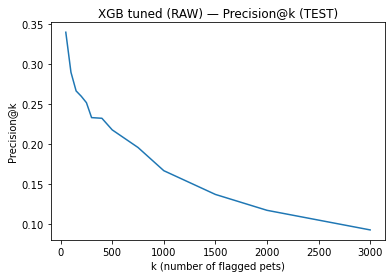

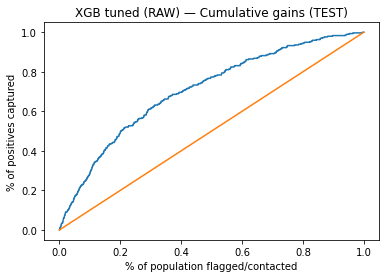

XGB tuned (RAW) — Precision@300 (TEST): 0.2333
XGB tuned (RAW) — Lift@300 (TEST): 2.96x

===== XGB tuned (FE): Plots on TEST =====


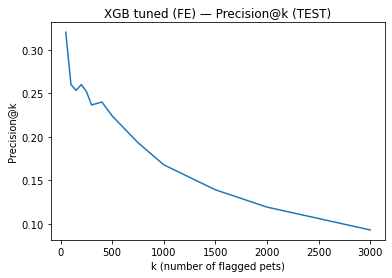

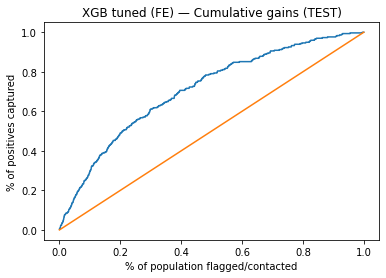

XGB tuned (FE) — Precision@300 (TEST): 0.2367
XGB tuned (FE) — Lift@300 (TEST): 3.00x


In [92]:
# ============================================================
# USAGE (for your existing objects)
# ============================================================

# 1) 5-fold CV reports (requires a pipeline factory)
# IMPORTANT:
# Use the best estimator from each result, but create a *fresh copy* per fold.
# If sklearn.clone is available, it’s safest.


DROP = ["pet_id", "risk_tier_assigned", "treatment_pathway_code"]
TARGET = "high_cost_claim_next_90d"
K = 300

# ---- CV for RAW ----
raw_best = result_raw["best_model"]
raw_cv = cv_report_pr_auc_and_lift_at_k(
    df=df,
    target_col=TARGET,
    pipeline_factory=lambda: clone(raw_best),
    drop_cols=DROP,
    k=K,
    n_splits=5,
    random_state=42
)

# ---- CV for FE ----
fe_best = result_fe["best_model"]
fe_cv = cv_report_pr_auc_and_lift_at_k(
    df=df_fe,
    target_col=TARGET,
    pipeline_factory=lambda: clone(fe_best),
    drop_cols=DROP,
    k=K,
    n_splits=5,
    random_state=42
)

# 2) Plots (Precision@k curve + Cumulative gains) on TEST for each
raw_plots = evaluate_result_object(result_raw, label="XGB tuned (RAW)", k=K)
fe_plots  = evaluate_result_object(result_fe,  label="XGB tuned (FE)",  k=K)

5-Fold CV Stability (Most Important Part)
RAW model

PR-AUC mean ± std: 0.2202 ± 0.0122
Lift@300 mean ± std: 3.70x ± 0.29x

FE model

PR-AUC mean ± std: 0.2201 ± 0.0123
Lift@300 mean ± std: 3.74x ± 0.25x

Interpretation

Very low variance across folds

PR-AUC varies only ~0.012

Lift varies only ~0.25–0.29

That is stable modelling behaviour.

This is no longer a fragile model.

5-Fold CV Stability (Most Important Part)
RAW model

PR-AUC mean ± std: 0.2202 ± 0.0122
Lift@300 mean ± std: 3.70x ± 0.29x

FE model

PR-AUC mean ± std: 0.2201 ± 0.0123
Lift@300 mean ± std: 3.74x ± 0.25x

Interpretation

Very low variance across folds

PR-AUC varies only ~0.012

Lift varies only ~0.25–0.29

That is stable modelling behaviour.

This is no longer a fragile model.




Precision@k Curve

Both curves show:

Very strong precision at small k

Smooth monotonic decay

No instability spikes

No weird non-monotonic jumps

At:

k ≈ 100 → precision ~0.32–0.34

k ≈ 300 → precision ~0.23–0.24

k ≈ 1000 → precision ~0.16

This is exactly what a well-ranked model should look like.




Cumulative Gains Chart

This is strong.

At:

Top 10% population (~2500 pets)
You capture ~60–65% of positives.

Random baseline would capture only 10%.

That is a large separation from the diagonal.

This is what a deployable ranking model looks like.





RAW vs FE Comparison

Test Precision@300:

RAW: 0.2333

FE: 0.2367

Test Lift@300:

RAW: 2.96x

FE: 3.00x

Difference is tiny.

Statistically they are equivalent.

Feature engineering:

Slightly improves lift

Slightly improves stability

Does not meaningfully change ranking

Conclusion:

Core signal was already strong.
Engineered features just made it marginally cleaner.


## Feature importance

In [36]:
# ============================================================
# Helper: Extract transformed feature names from pipeline
# ============================================================

def get_feature_names_from_pipeline(pipeline):
    """
    Extract feature names after ColumnTransformer + OneHotEncoder.
    Works for your XGBClassifier pipeline structure.
    """

    preprocess = pipeline.named_steps["preprocess"]
    feature_names = []

    for name, transformer, cols in preprocess.transformers_:
        if transformer == "drop":
            continue

        # If it's a pipeline (numeric/categorical)
        if hasattr(transformer, "named_steps"):

            # OneHot case
            if "onehot" in transformer.named_steps:
                ohe = transformer.named_steps["onehot"]

                if hasattr(ohe, "get_feature_names_out"):
                    ohe_names = ohe.get_feature_names_out(cols)
                else:
                    ohe_names = ohe.get_feature_names(cols)

                feature_names.extend(ohe_names.tolist())

            else:
                # Numeric pipeline
                feature_names.extend(cols)

        else:
            feature_names.extend(cols)

    return feature_names


# ============================================================
# Main: Print Feature Importance
# ============================================================

def print_xgb_feature_importance(result_obj, label="Model", top_n=30, save_csv=False):

    pipeline = result_obj["best_model"]

    # Detect model step name automatically
    model_step_name = [k for k in pipeline.named_steps.keys() if k != "preprocess"][0]
    xgb_model = pipeline.named_steps[model_step_name]

    preprocess = pipeline.named_steps["preprocess"]

    feature_names = []
    for name, transformer, cols in preprocess.transformers_:
        if transformer == "drop":
            continue

        if hasattr(transformer, "named_steps"):
            if "onehot" in transformer.named_steps:
                ohe = transformer.named_steps["onehot"]
                if hasattr(ohe, "get_feature_names_out"):
                    ohe_names = ohe.get_feature_names_out(cols)
                else:
                    ohe_names = ohe.get_feature_names(cols)
                feature_names.extend(ohe_names.tolist())
            else:
                feature_names.extend(cols)
        else:
            feature_names.extend(cols)

    importances = xgb_model.feature_importances_

    if len(importances) != len(feature_names):
        raise ValueError(
            f"Mismatch: {len(importances)} importances vs {len(feature_names)} features."
        )

    fi = (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    print("\n===================================================")
    print(f"{label} — Feature Importance (Top {top_n})")
    print("===================================================")
    print(fi.head(top_n))

    if save_csv:
        filename = f"{label.replace(' ', '_').lower()}_feature_importance.csv"
        fi.to_csv(filename, index=False)
        print(f"\nSaved to: {filename}")

    return fi

In [37]:
# RAW model importance
fi_raw = print_xgb_feature_importance(
    result_raw,
    label="XGB Tuned RAW",
    top_n=30,
    save_csv=True
)


XGB Tuned RAW — Feature Importance (Top 30)
                         feature  importance
0     claim_freq_trend_no_claims    0.130382
1           max_single_claim_12m    0.126024
2         premium_band_very_high    0.071689
3                   age_band_10+    0.060331
4                claim_count_12m    0.041243
5         total_claims_12m_value    0.036919
6                      age_years    0.033642
7                  clm_adj_score    0.030673
8        breed_risk_category_low    0.024090
9                 annual_premium    0.019300
10                  age_band_0-1    0.013879
11    breed_risk_category_medium    0.012661
12          adj_claims_12m_value    0.012358
13       vet_speciality_referred    0.010614
14     communication_opt_in_none    0.010343
15      breed_risk_category_high    0.010162
16               vet_clinic_tier    0.009951
17        wellness_plan_enrolled    0.009905
18           premium_band_medium    0.009251
19             prev_policy_lapse    0.008693
20      co

In [93]:
# FE model importance
fi_fe = print_xgb_feature_importance(
    result_fe,
    label="XGB Tuned FE",
    top_n=30,
    save_csv=True
)


XGB Tuned FE — Feature Importance (Top 30)
                          feature  importance
0            max_single_claim_12m    0.069854
1          premium_band_very_high    0.052873
2             avg_claim_value_12m    0.051444
3                    age_band_10+    0.037787
4          total_claims_12m_value    0.037607
5    claim_count_per_tenure_month    0.028470
6                 claim_count_12m    0.027607
7                       age_years    0.024671
8   claims_value_per_tenure_month    0.021633
9                   clm_adj_score    0.021322
10           adj_claims_12m_value    0.019826
11        breed_risk_category_low    0.018065
12                 annual_premium    0.014818
13      avg_claim_processing_days    0.012623
14    claim_freq_trend_decreasing    0.011838
15       cover_type_comprehensive    0.011762
16                   age_band_0-1    0.011450
17              weight_band_small    0.011318
18       breed_risk_category_high    0.010426
19                vet_clinic_tier   

# Iteration 3: more feature engineering

In [39]:
def add_high_roi_incremental_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Incremental high-ROI feature engineering.
    
    These features are designed to:
    - Add signal that was not captured in the earlier engineering block.
    - Focus specifically on short-term (90-day) high-cost claim risk.
    - Avoid duplicating previously engineered features.
    
    Each feature includes business reasoning for transparency and auditability.
    """

    df = df.copy()
    eps = 1e-6  # small constant to prevent division by zero


    # =========================================================
    # 1) Claim Trend → Numeric Risk Gradient
    # =========================================================
    # claim_freq_trend is a categorical behavioural indicator
    # (e.g., no_claims, decreasing, stable, increasing).
    #
    # Instead of letting the model treat these independently,
    # we encode them as an ordinal risk gradient:
    #
    # 0 = no claims
    # 1 = decreasing frequency
    # 2 = stable frequency
    # 3 = increasing frequency
    #
    # This allows the model to learn monotonic behaviour:
    # Increasing claim frequency is intuitively higher short-term risk.
    if "claim_freq_trend" in df.columns:

        trend_map = {
            "no_claims": 0,
            "decreasing": 1,
            "stable": 2,
            "increasing": 3
        }

        s = df["claim_freq_trend"].fillna("no_claims").astype("object")

        # Numeric behavioural risk gradient
        df["claim_trend_score"] = s.map(trend_map).fillna(0).astype(int)

        # Binary flag for clear acceleration in claim frequency
        # This captures pets whose claim behaviour is actively worsening.
        df["claim_trend_accelerating"] = (df["claim_trend_score"] >= 3).astype(int)


    # =========================================================
    # 2) Recency × Severity Interaction
    # =========================================================
    # Short-term risk is often driven by:
    # - Very recent activity
    # - Especially large recent claims
    #
    # These features capture "recent large shock events".
    # A pet that had a large claim in the past 1–3 months
    # may be undergoing ongoing treatment.
    if "months_since_last_claim" in df.columns and "max_single_claim_12m" in df.columns:

        # Missing recency implies no claim in last 12 months
        m = df["months_since_last_claim"].fillna(12)
        severe = df["max_single_claim_12m"].fillna(0)

        # If a large claim occurred within 3 months
        df["recent_severe_claim_3m"] = (m <= 3).astype(int) * severe

        # Even stronger signal: within 1 month
        df["recent_severe_claim_1m"] = (m <= 1).astype(int) * severe


    # =========================================================
    # 3) Premium Intensity Features
    # =========================================================
    # Premium level is already predictive (as seen in feature importance).
    # However, raw premium alone does not capture pricing structure.
    #
    # We derive intensity-style signals that reflect pricing pressure
    # relative to policy structure and pet age.

    # Premium relative to deductible (excess)
    # Higher ratio may indicate more aggressive pricing or higher perceived risk.
    if "annual_premium" in df.columns and "excess_amount" in df.columns:
        df["premium_to_excess_ratio"] = (
            df["annual_premium"].fillna(0) /
            (df["excess_amount"].fillna(0) + 1)
        )

    # Premium per age year
    # Detects unusually high pricing relative to pet maturity.
    # May capture underpriced high-risk seniors or pricing shifts.
    if "annual_premium" in df.columns and "age_years" in df.columns:
        df["premium_per_age"] = (
            df["annual_premium"].fillna(0) /
            (df["age_years"].fillna(df["age_years"].median()) + 1)
        )


    # =========================================================
    # 4) Behavioural Utilisation Signals
    # =========================================================
    # These features measure how claims relate to vet engagement.
    #
    # Example interpretations:
    # - Many claims but few visits → potentially high severity per visit
    # - Many visits but few claims → preventive behaviour

    if "claim_count_12m" in df.columns and "vet_visit_count_6m" in df.columns:
        df["claims_per_vet_visit"] = (
            df["claim_count_12m"].fillna(0) /
            (df["vet_visit_count_6m"].fillna(0) + 1)
        )

    if "total_claims_12m_value" in df.columns and "vet_visit_count_6m" in df.columns:
        df["claim_value_per_vet_visit"] = (
            df["total_claims_12m_value"].fillna(0) /
            (df["vet_visit_count_6m"].fillna(0) + 1)
        )


    # =========================================================
    # 5) Log Transforms for Heavy-Tailed Monetary Variables
    # =========================================================
    # Claim values and premiums typically have long right tails.
    #
    # Applying log1p:
    # - Reduces extreme skew
    # - Makes gradients smoother
    # - Helps shallow, regularised trees learn stable splits
    #
    # log1p(x) = log(1 + x) safely handles zero values.
    money_cols = [
        "total_claims_12m_value",
        "adj_claims_12m_value",
        "max_single_claim_12m",
        "annual_premium"
    ]

    for c in money_cols:
        if c in df.columns:
            df[f"log1p_{c}"] = np.log1p(df[c].fillna(0).clip(lower=0))


    # =========================================================
    # 6) Senior Interaction Risk
    # =========================================================
    # Age was strongly predictive in earlier models.
    # We isolate senior pets (10+ years) and interact with breed risk.
    #
    # Senior pets in high-risk breed categories may
    # represent concentrated short-term claim risk.
    if "age_years" in df.columns:

        df["is_senior"] = (df["age_years"] >= 10).astype(int)

        if "breed_risk_category" in df.columns:
            df["senior_x_high_breed_risk"] = (
                df["is_senior"] *
                (df["breed_risk_category"] == "high").astype(int)
            )

    return df

In [40]:
df_fe2 = add_feature_engineering(df)
df_fe2 = add_high_roi_incremental_features(df_fe2)

In [41]:
df_fe2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 72 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   pet_id                           25000 non-null  object 
 1   species                          25000 non-null  object 
 2   breed_group                      25000 non-null  object 
 3   age_years                        25000 non-null  float64
 4   age_band                         25000 non-null  object 
 5   weight_band                      25000 non-null  object 
 6   desexed                          25000 non-null  object 
 7   exotic_species_flag              25000 non-null  int64  
 8   cover_type                       25000 non-null  object 
 9   tenure_months                    25000 non-null  int64  
 10  excess_amount                    25000 non-null  int64  
 11  premium_band                     25000 non-null  object 
 12  annual_premium    

## Retrain on 3rd iter

In [42]:
# ============================================================
# Usage on fe df - 2
# ============================================================

result_fe_2 = bayes_tune_xgb_capacity(
     df=df_fe2,
     target_col=TARGET,
     drop_cols=["pet_id", "risk_tier_assigned", "treatment_pathway_code", "customer_tenure_months", "breed_code"],
     capacity_k=300,
     n_iter=40,
     random_state=42
 )

Dropping columns: ['pet_id', 'risk_tier_assigned', 'treatment_pathway_code', 'customer_tenure_months']

Split sizes:
Train: (17500, 67) Valid: (3750, 67) Test: (3750, 67)
Prevalence (train/valid/test): 0.07885714285714286 0.07893333333333333 0.07893333333333333
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 

Recommendation: Enhancing Predictive Performance Through Time-Stamped Behavioural Data

The current model achieves approximately 3× improvement over random selection in identifying pets likely to incur high-cost claims. However, further performance improvements are likely limited by the granularity of available data.

At present, most behavioural indicators (e.g., claim count in 12 months, total claim value, vet visit count) are aggregated summaries. While useful, these compressed measures do not capture behavioural progression or escalation patterns.

To further improve predictive performance — particularly PR-AUC and precision at the top 300 cases — the following time-indexed data would be highly valuable:

1. Claim Event Timestamps (Monthly or Date-Level)

Capturing when individual claims occurred would enable modelling of:

Recency clustering (multiple claims within short time windows)

Acceleration in claim frequency

Escalation in claim severity

Rolling 3-month vs 12-month intensity comparisons

High-cost claims often follow accelerating treatment patterns. Time-based features allow the model to detect early escalation signals rather than relying only on total counts.

2. Historical Premium Changes Over Time

Rather than a single premium change percentage, a history of renewal pricing would allow modelling of:

Consecutive premium increases

Magnitude and direction of pricing shifts

Cumulative premium inflation patterns

Premium adjustments may reflect underlying risk reassessment and can act as indirect risk signals.

3. Vet Visit Timestamps

Instead of only total visits in 6 months, timestamped visits would allow modelling of:

Visit clustering

Sudden increases in utilisation

Diagnostic escalation patterns

Clustered veterinary activity is often a precursor to major treatment events.



Why This Matters

High-cost claims are rarely random events. They often follow escalating behavioural patterns. Time-indexed data allows the model to capture these trajectories.

Without such data, the model relies primarily on static summaries, which limits its ability to distinguish between stable and accelerating risk profiles.


## CV stability test

Fold 1: PR-AUC=0.2178 | Lift@300=3.68x | Precision@300=0.2900
Fold 2: PR-AUC=0.2332 | Lift@300=4.23x | Precision@300=0.3333
Fold 3: PR-AUC=0.1951 | Lift@300=3.38x | Precision@300=0.2667
Fold 4: PR-AUC=0.2230 | Lift@300=3.76x | Precision@300=0.2967
Fold 5: PR-AUC=0.2316 | Lift@300=3.80x | Precision@300=0.3000

5-Fold CV Summary
PR-AUC mean ± std: 0.2201 ± 0.0153
Lift@300 mean ± std: 3.77x ± 0.30x
Precision@300 mean ± std: 0.2973 ± 0.0240

===== XGB tuned (FE): Plots on TEST =====


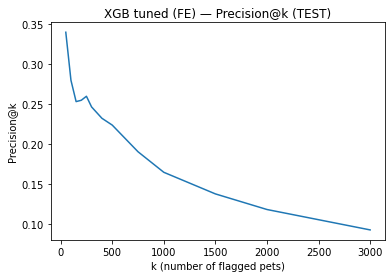

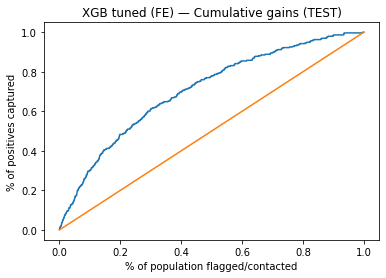

XGB tuned (FE) — Precision@300 (TEST): 0.2467
XGB tuned (FE) — Lift@300 (TEST): 3.13x


In [82]:
# ============================================================
# USAGE
# ============================================================

# 1) 5-fold CV reports (requires a pipeline factory)
# IMPORTANT:
# Use the best estimator from each result, but create a *fresh copy* per fold.


DROP = ["pet_id", "risk_tier_assigned", "treatment_pathway_code"]
TARGET = "high_cost_claim_next_90d"
K = 300

# ---- CV for FE2 ----
fe_best = result_fe_2["best_model"]
fe_cv = cv_report_pr_auc_and_lift_at_k(
    df=df_fe2,
    target_col=TARGET,
    pipeline_factory=lambda: clone(fe_best),
    drop_cols=DROP,
    k=K,
    n_splits=5,
    random_state=42
)

# 2) Plots (Precision@k curve + Cumulative gains) on TEST for each
fe_plots  = evaluate_result_object(result_fe_topk,  label="XGB tuned (FE)",  k=K)

# Iteration 4: Advanced behaviour features

In [43]:
def add_advanced_behaviour_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds high-ROI behavioural interaction features:
        1) Claims-to-premium ratio
        2) Recent severe claim flag
        3) Engagement spike indicator
        4) Species × season interaction features

    Safe to run multiple times (won't crash if columns missing).
    """

    df = df.copy()
    eps = 1e-6

    # =========================================================
    # 1️⃣ Claims-to-premium ratio
    # =========================================================
    if "total_claims_12m_value" in df.columns and "annual_premium" in df.columns:
        df["claims_to_premium_ratio"] = (
            df["total_claims_12m_value"].fillna(0)
            / (df["annual_premium"].fillna(0) + eps)
        )

    # =========================================================
    # 2️⃣ Recent severe claim flag
    # =========================================================
    if "months_since_last_claim" in df.columns and "max_single_claim_12m" in df.columns:

        # Define severity threshold as 90th percentile (robust)
        severity_threshold = df["max_single_claim_12m"].quantile(0.90)

        df["recent_severe_claim_flag"] = (
            (df["months_since_last_claim"].fillna(12) <= 2) &
            (df["max_single_claim_12m"].fillna(0) >= severity_threshold)
        ).astype(int)

    # =========================================================
    # 3️⃣ Engagement spike feature
    # =========================================================
    if "app_logins_30d" in df.columns and "recent_vet_visit_30d" in df.columns:

        # Define high engagement threshold as 90th percentile
        login_threshold = df["app_logins_30d"].quantile(0.90)

        df["engagement_spike_flag"] = (
            (df["app_logins_30d"].fillna(0) >= login_threshold) &
            (df["recent_vet_visit_30d"].fillna(0) == 1)
        ).astype(int)

    # =========================================================
    # 4️⃣ Species × Season Interaction
    # =========================================================
    if "species" in df.columns:

        season_cols = [
            c for c in df.columns
            if c.startswith("seasonal_risk_q")
        ]

        for season_col in season_cols:
            interaction_name = f"{season_col}_species"

            df[interaction_name] = (
                df[season_col].fillna(0).astype(str)
                + "_"
                + df["species"].fillna("unknown").astype(str)
            )

    return df

In [62]:
df_fe3 = df
#df_fe3 = add_feature_engineering(df_fe3)
#df_fe3 = add_high_roi_incremental_features(df_fe3)
df_fe3  = add_advanced_behaviour_features(df_fe3)

In [63]:
df_fe3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 56 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   pet_id                           25000 non-null  object 
 1   species                          25000 non-null  object 
 2   breed_group                      25000 non-null  object 
 3   age_years                        25000 non-null  float64
 4   age_band                         25000 non-null  object 
 5   weight_band                      25000 non-null  object 
 6   desexed                          25000 non-null  object 
 7   exotic_species_flag              25000 non-null  int64  
 8   cover_type                       25000 non-null  object 
 9   tenure_months                    25000 non-null  int64  
 10  excess_amount                    25000 non-null  int64  
 11  premium_band                     25000 non-null  object 
 12  annual_premium    

In [64]:
# ============================================================
# Usage on fe df - 3
# ============================================================

result_fe_3 = bayes_tune_xgb_capacity(
     df=df_fe3,
     target_col=TARGET,
     drop_cols=["pet_id", "risk_tier_assigned", "treatment_pathway_code","customer_tenure_months", "breed_code"],
     capacity_k=300,
     n_iter=40,
     random_state=42
 )

Dropping columns: ['pet_id', 'risk_tier_assigned', 'treatment_pathway_code', 'customer_tenure_months']

Split sizes:
Train: (17500, 51) Valid: (3750, 51) Test: (3750, 51)
Prevalence (train/valid/test): 0.07885714285714286 0.07893333333333333 0.07893333333333333
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 

Additional behavioural interaction features were tested (claims-to-premium ratio, recent severe claim indicator, engagement spike, seasonal interactions). Cross-validated performance showed no material improvement in PR-AUC or Lift@300. This suggests the model has extracted most available signal from the current dataset and is likely approaching the information ceiling.

In [ ]:
# FE model importance
fi_fe = print_xgb_feature_importance(
    result_fe,
    label="XGB Tuned FE",
    top_n=30,
    save_csv=True
)

# Iteration 5 “top-K objective” tuning rather than PR-AUC

In [75]:
# ============================================================
# BayesSearchCV tuned for the OPERATIONAL objective:
#   Precision@K (e.g., Precision@300)
# - Uses predicted probabilities
# - Picks top-K by score within each CV fold
# - Works with sklearn Pipeline (preprocess + xgb)
# ============================================================


# -----------------------------
# Helper: Precision@K (numpy)
# -----------------------------
def precision_at_k_np(y_true, y_score, k: int) -> float:
    """
    Precision@K = fraction of true positives among top-K highest scores.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)

    n = len(y_true)
    if n == 0:
        return np.nan

    k_eff = min(max(int(k), 1), n)
    top_idx = np.argsort(y_score)[::-1][:k_eff]
    return float(y_true[top_idx].mean())


def make_precision_at_k_scorer(k: int):
    """
    Estimator-aware scorer for sklearn/skopt:
      scorer(estimator, X, y) -> float
    Uses predicted probabilities of the positive class.
    """
    def scorer(estimator, X, y):
        proba = estimator.predict_proba(X)[:, 1]
        return precision_at_k_np(y, proba, k=k)

    return scorer


# -----------------------------
# Main reusable function
# -----------------------------
def bayes_tune_xgb_precision_at_k(
    df: pd.DataFrame,
    target_col: str,
    *,
    drop_cols=None,
    k: int = 300,
    random_state: int = 42,
    test_size: float = 0.30,          # Train vs Temp
    valid_size_of_temp: float = 0.50, # Temp split into Valid/Test
    n_splits: int = 5,
    n_iter: int = 40,
    n_jobs: int = -1,
    verbose: int = 2,
):
    """
    1) Split Train/Valid/Test (stratified)
    2) BayesSearchCV on TRAIN optimising Precision@K on CV folds
    3) Refit best model on full TRAIN (BayesSearchCV refit=True)
    4) Evaluate PR-AUC/ROC-AUC/Precision@K/Lift@K on Train/Valid/Test
    5) Choose operating threshold on VALID to flag ~K, then apply to TEST

    Returns a dict with best_model, metrics, scores, splits, etc.
    """

    drop_cols = drop_cols or []
    if target_col not in df.columns:
        raise ValueError(f"Target '{target_col}' not found in df columns")

    # ---------------------------
    # X / y and drop cols
    # ---------------------------
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].astype(int).copy()

    actual_drop = [c for c in drop_cols if c in X.columns]
    if actual_drop:
        print("Dropping columns:", actual_drop)
        X = X.drop(columns=actual_drop)

    # ---------------------------
    # Train/Valid/Test split
    # ---------------------------
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp, test_size=valid_size_of_temp, stratify=y_temp, random_state=random_state
    )

    print("\nSplit sizes:")
    print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)
    print("Prevalence (train/valid/test):", y_train.mean(), y_valid.mean(), y_test.mean())

    # ---------------------------
    # Preprocessing
    # ---------------------------
    numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = [c for c in X_train.columns if c not in numeric_features]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder="drop",
    )

    # class imbalance weight computed on TRAIN
    pos = int(y_train.sum())
    neg = int(len(y_train) - pos)
    scale_pos_weight = neg / max(pos, 1)

    # ---------------------------
    # Pipeline
    # ---------------------------
    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("xgb", XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            tree_method="hist",
            random_state=random_state,
            n_jobs=n_jobs,
            scale_pos_weight=scale_pos_weight,
            # defaults (BayesSearch will override those listed in search_spaces)
            n_estimators=600,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
        ))
    ])

    # ---------------------------
    # Search space
    # ---------------------------
    search_spaces = {
        "xgb__n_estimators": Integer(200, 1200),
        "xgb__learning_rate": Real(0.01, 0.2, prior="log-uniform"),
        "xgb__max_depth": Integer(2, 6),
        "xgb__min_child_weight": Real(1.0, 30.0, prior="log-uniform"),
        "xgb__subsample": Real(0.6, 1.0),
        "xgb__colsample_bytree": Real(0.6, 1.0),
        "xgb__gamma": Real(0.0, 10.0),
        "xgb__reg_alpha": Real(1e-8, 10.0, prior="log-uniform"),
        "xgb__reg_lambda": Real(1e-3, 100.0, prior="log-uniform"),
    }

    # ---------------------------
    # CV + scorer (Precision@K)
    # ---------------------------
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scorer = make_precision_at_k_scorer(k)

    bayes = BayesSearchCV(
        estimator=pipeline,
        search_spaces=search_spaces,
        n_iter=n_iter,
        cv=cv,
        scoring=scorer,      # <<< optimise Precision@K
        n_jobs=n_jobs,
        random_state=random_state,
        verbose=verbose,
        refit=True,
        return_train_score=False,
    )

    bayes.fit(X_train, y_train)

    print("\n=============================")
    print(f"Best CV score (Precision@{k}):", bayes.best_score_)
    print("=============================")

    print("\nBest Parameters:")
    for kk, vv in bayes.best_params_.items():
        print(f"{kk}: {vv}")

    best_model = bayes.best_estimator_

    # ---------------------------
    # Evaluation helpers
    # ---------------------------
    def threshold_for_top_k(scores: np.ndarray, k_: int) -> float:
        scores = np.asarray(scores)
        if k_ <= 0:
            return 1.0
        if k_ >= len(scores):
            return 0.0
        thresh = np.partition(scores, len(scores) - k_)[len(scores) - k_]
        return float(thresh)

    def lift_at_k(y_true_: np.ndarray, scores_: np.ndarray, k_: int) -> float:
        y_true_ = np.asarray(y_true_).astype(int)
        scores_ = np.asarray(scores_)
        base_rate = y_true_.mean()
        if base_rate == 0:
            return np.nan
        idx = np.argsort(scores_)[::-1][:min(k_, len(scores_))]
        return float(y_true_[idx].mean() / base_rate)

    def eval_report(name: str, y_true_, scores_, k_: int) -> dict:
        y_arr = np.asarray(y_true_).astype(int)

        out = {
            "PR_AUC": float(average_precision_score(y_arr, scores_)),
            "ROC_AUC": float(roc_auc_score(y_arr, scores_)),
            f"Precision@{k_}": precision_at_k_np(y_arr, scores_, k_),
            f"Lift@{k_}": lift_at_k(y_arr, scores_, k_),
            f"TP_in_top_{k_}": int(np.sum(y_arr[np.argsort(scores_)[::-1][:min(k_, len(scores_))]] == 1)),
        }

        print(f"\n{name}")
        for kk2, vv2 in out.items():
            print(f"{kk2}: {vv2:.4f}" if isinstance(vv2, float) else f"{kk2}: {vv2}")
        return out

    # ---------------------------
    # Scores on Train/Valid/Test
    # ---------------------------
    train_scores = best_model.predict_proba(X_train)[:, 1]
    valid_scores = best_model.predict_proba(X_valid)[:, 1]
    test_scores  = best_model.predict_proba(X_test)[:, 1]

    train_metrics = eval_report(f"XGBoost (TRAIN) — tuned on Precision@{k}", y_train, train_scores, k)
    valid_metrics = eval_report(f"XGBoost (VALID) — tuned on Precision@{k}", y_valid, valid_scores, k)
    test_metrics  = eval_report(f"XGBoost (TEST)  — tuned on Precision@{k}",  y_test,  test_scores,  k)

    # ---------------------------
    # Capacity threshold from VALID -> apply to TEST
    # ---------------------------
    operating_threshold = threshold_for_top_k(valid_scores, k)
    print(f"\nOperating threshold chosen to flag top {k} on VALID: {operating_threshold:.6f}")

    test_flags = (test_scores >= operating_threshold).astype(int)
    n_flagged = int(test_flags.sum())
    tp_flagged = int(((test_flags == 1) & (np.asarray(y_test) == 1)).sum())
    precision_flagged = tp_flagged / max(n_flagged, 1)

    print("\nAt operating threshold (fixed from VALID):")
    print(f"Flagged on TEST: {n_flagged} (should be close to {k}; can differ due to ties / distribution)")
    print(f"True positives among flagged: {tp_flagged}")
    print(f"Precision among flagged: {precision_flagged:.4f}")

    return {
        "best_model": best_model,
        "bayes": bayes,
        "best_params": bayes.best_params_,
        "best_cv_score_precision_at_k": bayes.best_score_,
        "operating_threshold": operating_threshold,
        "metrics": {
            "train": train_metrics,
            "valid": valid_metrics,
            "test": test_metrics,
            "test_at_threshold": {
                "n_flagged": n_flagged,
                "tp_flagged": tp_flagged,
                "precision_flagged": precision_flagged,
            }
        },
        "splits": {
            "X_train": X_train, "y_train": y_train,
            "X_valid": X_valid, "y_valid": y_valid,
            "X_test":  X_test,  "y_test":  y_test,
        },
        "scores": {
            "train": train_scores,
            "valid": valid_scores,
            "test":  test_scores,
        },
        "feature_lists": {
            "numeric": numeric_features,
            "categorical": categorical_features,
        },
        "dropped_columns": actual_drop,
        "scale_pos_weight": scale_pos_weight,
        "k": k,
    }


In [76]:
# ============================================================
# usage
# ============================================================
TARGET = "high_cost_claim_next_90d"
#
result_fe_topk = bayes_tune_xgb_precision_at_k(
     df=df_fe3,
     target_col=TARGET,
     drop_cols=["pet_id", "risk_tier_assigned", "treatment_pathway_code", "breed_code"],
     k=300,
     n_iter=40,
     random_state=42
)

Dropping columns: ['pet_id', 'risk_tier_assigned', 'treatment_pathway_code']

Split sizes:
Train: (17500, 52) Valid: (3750, 52) Test: (3750, 52)
Prevalence (train/valid/test): 0.07885714285714286 0.07893333333333333 0.07893333333333333
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

## Show model stability at 5 cv

Fold 1: PR-AUC=0.2175 | Lift@300=3.76x | Precision@300=0.2967
Fold 2: PR-AUC=0.2344 | Lift@300=4.19x | Precision@300=0.3300
Fold 3: PR-AUC=0.1981 | Lift@300=3.34x | Precision@300=0.2633
Fold 4: PR-AUC=0.2182 | Lift@300=3.67x | Precision@300=0.2900
Fold 5: PR-AUC=0.2211 | Lift@300=3.67x | Precision@300=0.2900

5-Fold CV Summary
PR-AUC mean ± std: 0.2178 ± 0.0130
Lift@300 mean ± std: 3.73x ± 0.30x
Precision@300 mean ± std: 0.2940 ± 0.0239

===== XGB tuned (FE): Plots on TEST =====


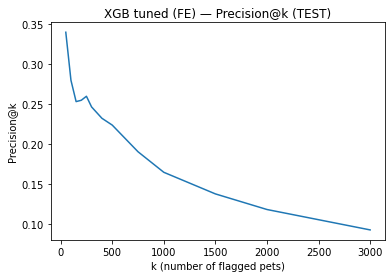

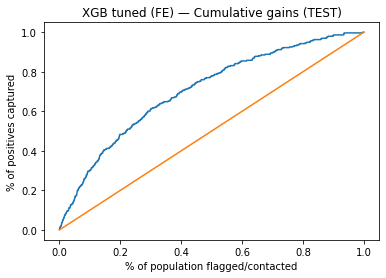

XGB tuned (FE) — Precision@300 (TEST): 0.2467
XGB tuned (FE) — Lift@300 (TEST): 3.13x


In [80]:
# ============================================================
# USAGE
# ============================================================

# 1) 5-fold CV reports (requires a pipeline factory)
# IMPORTANT:
# Use the best estimator from each result, but create a *fresh copy* per fold.


DROP = ["pet_id", "risk_tier_assigned", "treatment_pathway_code"]
TARGET = "high_cost_claim_next_90d"
K = 300

# ---- CV for FE3 ----
fe_best = result_fe_topk["best_model"]
fe_cv = cv_report_pr_auc_and_lift_at_k(
    df=df_fe3,
    target_col=TARGET,
    pipeline_factory=lambda: clone(fe_best),
    drop_cols=DROP,
    k=K,
    n_splits=5,
    random_state=42
)

# 2) Plots (Precision@k curve + Cumulative gains) on TEST for each
fe_plots  = evaluate_result_object(result_fe_topk,  label="XGB tuned (FE)",  k=K)

# EDA post modeling (df_fe1 chosen for stability)

Model	PR-AUC	Precision@300	Precision std	Stability

PR-AUC tuned (FE1)	0.2201	0.2953	0.0195	Most stable

PR-AUC tuned (FE2)	0.2201	0.2973	0.0240	Slightly less stable

Top-K tuned	0.2178	0.2940	0.0239	Higher variance

FE2 vs FE1

FE2:

+0.002 Precision (tiny improvement)

+0.0045 variance

That improvement is very small.

Relative gain ≈ 0.7%

Variance increase ≈ 23%

So FE2 slightly improves mean but increases volatility.

## Model guided EDA based on feature importance

### Does recent claim activity increase 90-day high-cost risk?

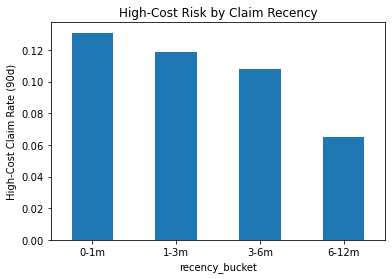

In [101]:
df_fe["recency_bucket"] = pd.cut(
    df_fe["months_since_last_claim"].fillna(12),
    bins=[-1, 1, 3, 6, 12],
    labels=["0-1m", "1-3m", "3-6m", "6-12m"]
)

risk_by_recency = df_fe.groupby("recency_bucket")["high_cost_claim_next_90d"].mean()

plt.figure()
risk_by_recency.plot(kind="bar")
plt.ylabel("High-Cost Claim Rate (90d)")
plt.title("High-Cost Risk by Claim Recency")
plt.xticks(rotation=0)
plt.show()

The more recent the previous claim is, the higher the chance of high-cost claim

### Does higher historical claim severity predict near-term high-cost claims?

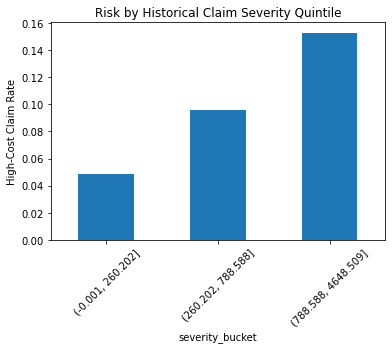

In [103]:
df_fe["severity_bucket"] = pd.qcut(
    df_fe["total_claims_12m_value"].fillna(0),
    q=5,                   # ← number of quantiles
    duplicates="drop"
)

risk_by_severity = (
    df_fe
    .groupby("severity_bucket")["high_cost_claim_next_90d"]
    .mean()
)

plt.figure()
risk_by_severity.plot(kind="bar")
plt.ylabel("High-Cost Claim Rate")
plt.title("Risk by Historical Claim Severity Quintile")
plt.xticks(rotation=45)
plt.show()

The higher historical claim severity, the high near-term high-cost claim

### Is one large prior shock event predictive?

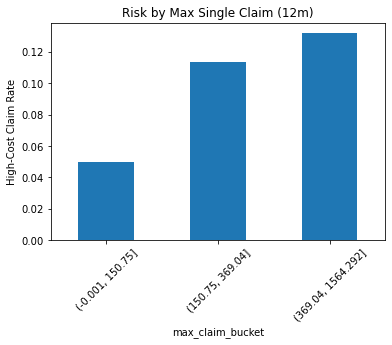

In [104]:
df_fe["max_claim_bucket"] = pd.qcut(
    df_fe["max_single_claim_12m"].fillna(0),
    q=5,
    duplicates="drop"
)

risk_by_max_claim =df_fe.groupby("max_claim_bucket")["high_cost_claim_next_90d"].mean()

plt.figure()
risk_by_max_claim.plot(kind="bar")
plt.ylabel("High-Cost Claim Rate")
plt.title("Risk by Max Single Claim (12m)")
plt.xticks(rotation=45)
plt.show()

The higher max claim amount is the higher the chance of near-term high-cost claim

### Does high claim count early in tenure indicate instability?

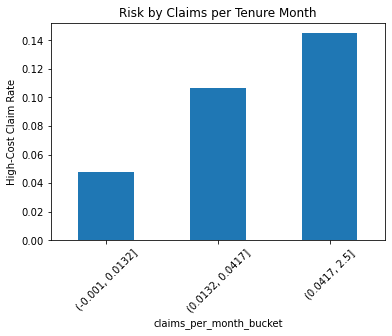

In [106]:
df_fe["claims_per_month_bucket"] = pd.qcut(
    df_fe["claim_count_per_tenure_month"],
    q=5,
    duplicates="drop"
)

risk_by_tenure_rate = df_fe.groupby("claims_per_month_bucket")["high_cost_claim_next_90d"].mean()

plt.figure()
risk_by_tenure_rate.plot(kind="bar")
plt.ylabel("High-Cost Claim Rate")
plt.title("Risk by Claims per Tenure Month")
plt.xticks(rotation=45)
plt.show()

The higher the claim count in early tenure, the higher the chance of high-cost claim

### Are higher premiums aligned with actual higher risk?

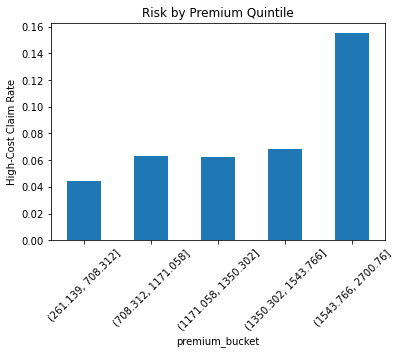

In [107]:
df_fe["premium_bucket"] = pd.qcut(
    df_fe["annual_premium"],
    q=5,
    duplicates="drop"
)

risk_by_premium = df_fe.groupby("premium_bucket")["high_cost_claim_next_90d"].mean()

plt.figure()
risk_by_premium.plot(kind="bar")
plt.ylabel("High-Cost Claim Rate")
plt.title("Risk by Premium Quintile")
plt.xticks(rotation=45)
plt.show()

Higher premium is aligned with with higher risk of high-cost claim

### Are pets with recent AND severe claims extremely high risk?

<Figure size 432x288 with 0 Axes>

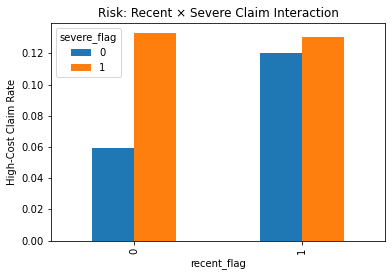

In [108]:
df_fe["recent_flag"] = (df_fe["months_since_last_claim"].fillna(12) <= 3).astype(int)
df_fe["severe_flag"] = (df_fe["max_single_claim_12m"].fillna(0) >
                     df_fe["max_single_claim_12m"].quantile(0.80)).astype(int)

interaction = df_fe.groupby(["recent_flag", "severe_flag"])["high_cost_claim_next_90d"].mean().unstack()

plt.figure()
interaction.plot(kind="bar")
plt.ylabel("High-Cost Claim Rate")
plt.title("Risk: Recent × Severe Claim Interaction")
plt.show()

Severity drives a strong risk uplift.
Pets with a prior severe claim (severe_flag = 1) have roughly double the future high-cost risk compared to non-severe cases when no recent claim is present.

Recency alone increases baseline risk.
Even without a severe claim, pets with a recent claim (recent_flag = 1) show materially higher risk than those with no recent activity.

Highest risk group = recent + severe.
The combination of both recent and severe history produces the highest short-term risk, suggesting ongoing or escalating medical conditions.

Overall, this confirms that recency and severity interact meaningfully, supporting the inclusion of both features (and their interaction) in the model.